# Laboratorio 1 — Series de Tiempo · Notebook 1 de 2
### Ingreso de viajeros internacionales a Guatemala (2009 – jun 2026)

### Integrantes
- Nicolas Concua
- Felipe Aguilar

> **Este es el Notebook 1 de 2.** Contiene el análisis exploratorio (compartido) y las series de
> *Total* y *Vías de ingreso*. Las series por **País de residencia** están en el **Notebook 2**
> (`Lab1_Series_Paises.ipynb`). Ver `README.md` para la división del trabajo.

Este cuaderno contiene el **avance**: (1) análisis exploratorio general del conjunto de datos y
(2) análisis preliminar de dos series de tiempo. La entrega final ampliará el modelado
(ARIMA/SARIMA, Prophet, Holt-Winters, etc.) sobre las categorías seleccionadas.

**Categorías seleccionadas para el laboratorio completo:** *Vías de ingreso* y *Países de residencia*.

**Series analizadas en este avance:**
1. **Total mensual de viajeros internacionales** (definida como `Turista + Excursionista`, consistente en todo el período).
2. **Vía de ingreso Aérea**.

> **Nota de datos.** Los datos son de uso exclusivamente académico; no son cifras oficiales del INGUAT ni del IGM.

## 0. Instalación de dependencias

Si te falta alguna librería, descomenta y ejecuta la siguiente celda. Para el **avance** basta con
el stack de análisis (`pandas`, `numpy`, `matplotlib`, `seaborn`, `statsmodels`, `openpyxl`).
Las librerías de modelado (`pmdarima`, `prophet`) se usarán en la entrega final.

In [1]:
# !pip install numpy pandas matplotlib seaborn statsmodels scikit-learn openpyxl
# Para la entrega final:
# !pip install pmdarima prophet

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42
print("Entorno listo.")

Entorno listo.


## 1. Carga de datos y primer vistazo

El archivo `Base_Migracion_2009-2026jun.xlsx` tiene dos hojas: **`Datos`** (los registros) y
**`Notas`** (contexto metodológico). Trabajaremos con `Datos`, que está en **formato largo**:
una fila por combinación de mes × vía × frontera × país/agrupación × tipo de viajero, con la
cantidad en la columna `Viajero`.

In [3]:
ARCHIVO = "Base_Migracion_2009-2026jun.xlsx"

df = pd.read_excel(ARCHIVO, sheet_name="Datos")
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 161,036 filas x 13 columnas


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.00
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.00
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.00
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.00
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.00


In [4]:
# Tipos de dato y memoria
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Año                    161036 non-null  int64  
 1   Mes cod                161036 non-null  int64  
 2   Mes                    161036 non-null  str    
 3   Vía                    161036 non-null  str    
 4   Frontera               161036 non-null  str    
 5   País                   161036 non-null  str    
 6   Región                 161036 non-null  str    
 7   Región dos             161036 non-null  str    
 8   Regiones OMT           161036 non-null  str    
 9   MCEO                   161036 non-null  str    
 10  Agrupación Residencia  161036 non-null  str    
 11  Tipo de Viajero        161036 non-null  str    
 12  Viajero                161036 non-null  float64
dtypes: float64(1), int64(2), str(10)
memory usage: 16.0 MB


### 1.1 Construcción del índice temporal

Combinamos `Año` y `Mes cod` en una **fecha mensual** (primer día de cada mes, `freq='MS'`).
Esto nos permitirá luego agregar y construir las series de tiempo.

In [5]:
df["Fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes cod"], day=1))
print("Rango temporal:", df["Fecha"].min().date(), "->", df["Fecha"].max().date())
print("Meses únicos:", df["Fecha"].nunique(), "(esperado 210: ene-2009 a jun-2026)")

# Verificamos que NO haya huecos en el eje temporal mensual
rango_completo = pd.date_range(df["Fecha"].min(), df["Fecha"].max(), freq="MS")
faltantes = rango_completo.difference(df["Fecha"].unique())
print("Meses faltantes en el calendario:", len(faltantes))

Rango temporal: 2009-01-01 -> 2026-06-01
Meses únicos: 210 (esperado 210: ene-2009 a jun-2026)
Meses faltantes en el calendario: 0


## 2. Análisis de calidad: faltantes, duplicados y atípicos

*(Requisito 1e del enunciado.)*

### 2.1 Valores faltantes

In [6]:
faltantes_tabla = pd.DataFrame({
    "n_nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(2)
})
faltantes_tabla

,n_nulos,%_nulos
Año,0,0.00
Mes cod,0,0.00
Mes,0,0.00
Vía,0,0.00
Frontera,0,0.00
País,0,0.00
Región,0,0.00
Región dos,0,0.00
Regiones OMT,0,0.00
MCEO,0,0.00


### 2.2 Duplicados

Buscamos filas idénticas y también duplicados en la **clave lógica** (la combinación de dimensiones
que identifica un registro para un mismo mes). Un duplicado real provocaría doble conteo.

In [7]:
dup_exactos = df.duplicated().sum()

# Clave lógica COMPLETA: incluye 'Agrupación Residencia', la dimensión más fina.
clave_full = ["Fecha", "Vía", "Frontera", "País", "Tipo de Viajero", "Agrupación Residencia"]
dup_full = df.duplicated(subset=clave_full).sum()

# Clave SIN 'Agrupación Residencia': revela registros que solo difieren en esa dimensión.
clave_reducida = ["Fecha", "Vía", "Frontera", "País", "Tipo de Viajero"]
dup_reducida = df.duplicated(subset=clave_reducida).sum()

print(f"Duplicados exactos (fila completa): {dup_exactos}")
print(f"Duplicados en la clave lógica completa {clave_full}: {dup_full}")
print(f"'Duplicados' si se ignora 'Agrupación Residencia': {dup_reducida}")

# Inspeccionamos esos casos: ¿son doble conteo o un desglose más fino?
mask_dup = df.duplicated(subset=clave_reducida, keep=False)
ejemplo = (df[mask_dup]
           .sort_values(clave_reducida)
           [clave_reducida + ["Región dos", "Agrupación Residencia", "Viajero"]])
print(f"\nRegistros involucrados: {mask_dup.sum()} (en {df[mask_dup].groupby(clave_reducida).ngroups} grupos)")
print("¿Difiere 'Región dos' dentro de un grupo?:",
      (df[mask_dup].groupby(clave_reducida)["Región dos"].nunique() > 1).any())
ejemplo.head(6)

Duplicados exactos (fila completa): 0
Duplicados en la clave lógica completa ['Fecha', 'Vía', 'Frontera', 'País', 'Tipo de Viajero', 'Agrupación Residencia']: 0
'Duplicados' si se ignora 'Agrupación Residencia': 22



Registros involucrados: 42 (en 20 grupos)
¿Difiere 'Región dos' dentro de un grupo?: False


,Fecha,Vía,Frontera,País,Tipo de Viajero,Región dos,Agrupación Residencia,Viajero
130128,2020-12-01,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Europa,Europa,3.00
130129,2020-12-01,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Europa,Resto del Mundo,1.00
131981,2021-05-01,Aérea,01 La Aurora,Federación de Rusia,Turista,Europa,Europa,44.00
131982,2021-05-01,Aérea,01 La Aurora,Federación de Rusia,Turista,Europa,Resto del Mundo,223.00
132717,2021-06-01,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Europa,Europa,4.00
132718,2021-06-01,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,Europa,Resto del Mundo,1.00


**Interpretación (duplicados).** No hay **ningún** duplicado real: con la clave lógica completa
(incluyendo `Agrupación Residencia`) el conteo es **0**. Los ~20 casos que aparecerían al ignorar
esa columna **no son doble conteo**, sino un país repartido en dos agrupaciones de residencia
distintas (p. ej. *Colombia* dividida entre "Colombia" y "Otros Suramérica"). Como la `Región dos`
es idéntica dentro de cada grupo, **nuestras agregaciones por fecha, vía, país o región no se ven
afectadas**: al sumar, esas filas se combinan correctamente.

### 2.3 Valores atípicos de la medida `Viajero`

La columna `Viajero` trae **decimales** porque son estimaciones de encuesta expandidas (no
conteos exactos). Revisamos su distribución, ceros y valores extremos con un boxplot en escala
logarítmica (la variable es muy asimétrica).

count   161,036.00
mean        324.70
std       2,387.75
min           0.00
25%           2.00
50%           7.00
75%          38.89
max      92,336.04
Name: Viajero, dtype: float64

Filas con Viajero == 0: 54
Filas con Viajero < 0 : 0


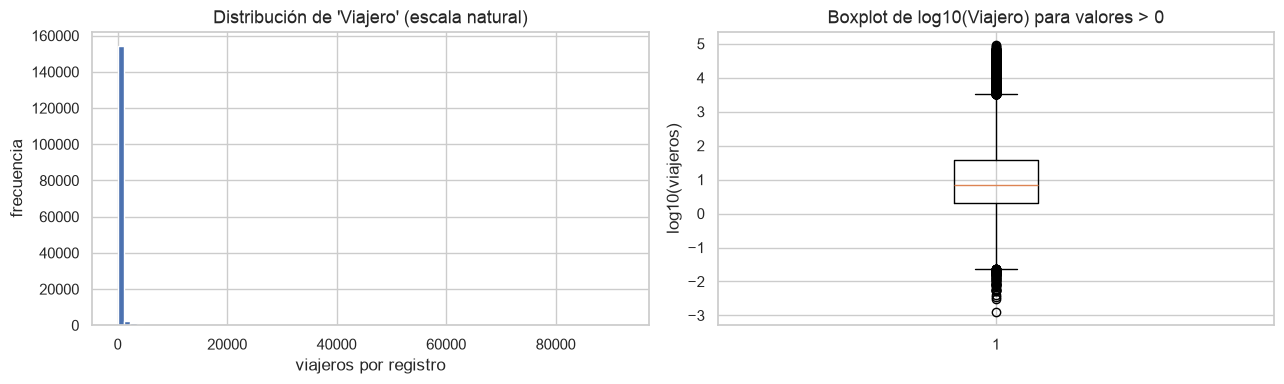

In [8]:
print(df["Viajero"].describe())
print("\nFilas con Viajero == 0:", (df["Viajero"] == 0).sum())
print("Filas con Viajero < 0 :", (df["Viajero"] < 0).sum())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(df["Viajero"], bins=80, color="#4c72b0")
ax[0].set_title("Distribución de 'Viajero' (escala natural)")
ax[0].set_xlabel("viajeros por registro"); ax[0].set_ylabel("frecuencia")

positivos = df.loc[df["Viajero"] > 0, "Viajero"]
ax[1].boxplot(np.log10(positivos), vert=True)
ax[1].set_title("Boxplot de log10(Viajero) para valores > 0")
ax[1].set_ylabel("log10(viajeros)")
plt.tight_layout(); plt.show()

**Interpretación (calidad).** El conjunto llega **muy limpio**: sin valores nulos, sin duplicados
exactos ni duplicados de clave lógica, y sin cantidades negativas. La medida `Viajero` es
fuertemente asimétrica (muchos registros pequeños de países/fronteras menores y pocos registros
muy grandes de mercados dominantes), por lo que los "atípicos" del boxplot **no son errores** sino
la cola natural de la distribución. Los decimales son esperados (estimaciones expandidas). No se
requiere imputación ni eliminación de filas para el análisis agregado.

## 3. Comportamiento temporal del número de viajeros

*(Requisito 1a.)* Agregamos el total mensual de viajeros (todos los tipos) para ver la evolución
global. Marcamos el inicio de la pandemia (mar-2020) y señalamos que **2026 es un año parcial**
(solo enero–junio), por lo que las comparaciones anuales de 2026 no son directas.

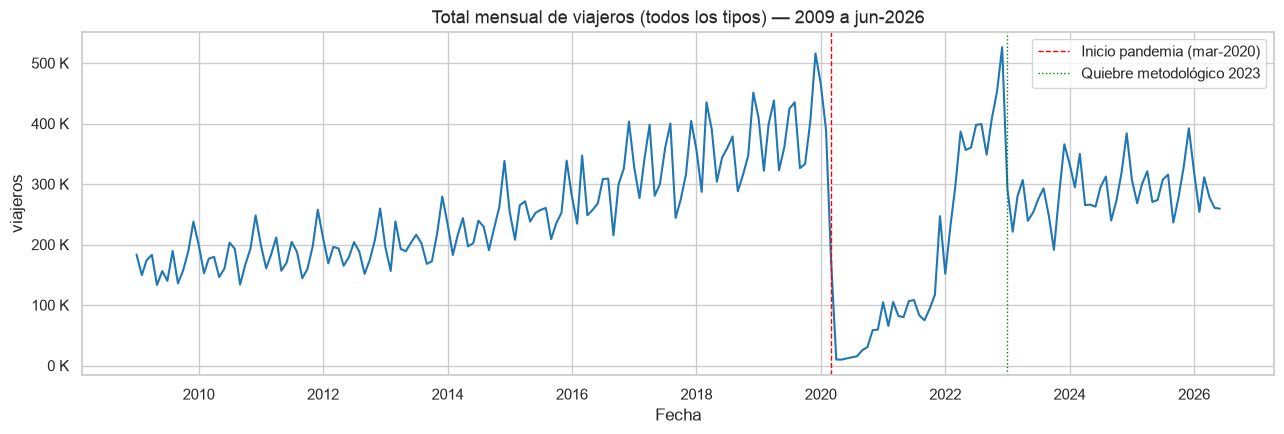

In [9]:
serie_total_bruta = df.groupby("Fecha")["Viajero"].sum()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(serie_total_bruta.index, serie_total_bruta.values, color="#1f77b4")
ax.axvline(pd.Timestamp("2020-03-01"), color="red", ls="--", lw=1, label="Inicio pandemia (mar-2020)")
ax.axvline(pd.Timestamp("2023-01-01"), color="green", ls=":", lw=1, label="Quiebre metodológico 2023")
ax.set_title("Total mensual de viajeros (todos los tipos) — 2009 a jun-2026")
ax.set_xlabel("Fecha"); ax.set_ylabel("viajeros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f} K"))
ax.legend(); plt.tight_layout(); plt.show()

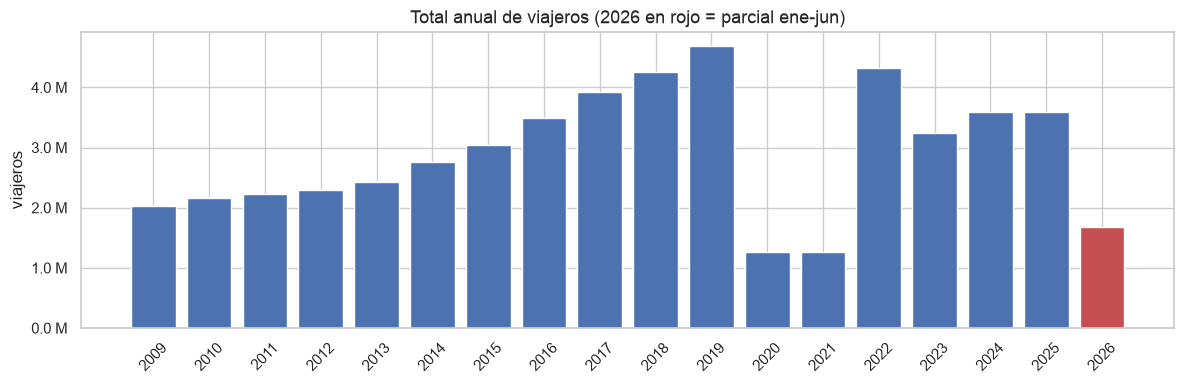

In [10]:
# Total ANUAL (marcamos 2026 como parcial)
tot_anual = df.groupby("Año")["Viajero"].sum()
fig, ax = plt.subplots(figsize=(12, 4))
colores = ["#c44e52" if a == 2026 else "#4c72b0" for a in tot_anual.index]
ax.bar(tot_anual.index.astype(str), tot_anual.values, color=colores)
ax.set_title("Total anual de viajeros (2026 en rojo = parcial ene-jun)")
ax.set_ylabel("viajeros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.1f} M"))
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

**Interpretación (temporal).** Se observan tres rasgos:
1. **Estacionalidad anual** clara (picos y valles que se repiten cada 12 meses).
2. El **colapso de la pandemia** en mar-2020 y el piso 2020–2021, con recuperación desde 2022.
3. El **quiebre metodológico de 2023** (línea verde), tras el cual la categoría "Viajero" se
   reclasifica; por eso más adelante trabajamos la serie total como `Turista + Excursionista`,
   que sí es comparable en todo el rango.

## 4. Composición por tipo de viajero y justificación de la serie total

El enunciado y las Notas advierten que la categoría **"Viajero"** (comercio fronterizo, tránsito)
cae artificialmente en 2023 por reclasificación, y que **"Cruceristas"** solo existe hasta 2022.
Para una serie comparable en todo el período se recomienda **Turista + Excursionista**. Lo
verificamos visualmente.

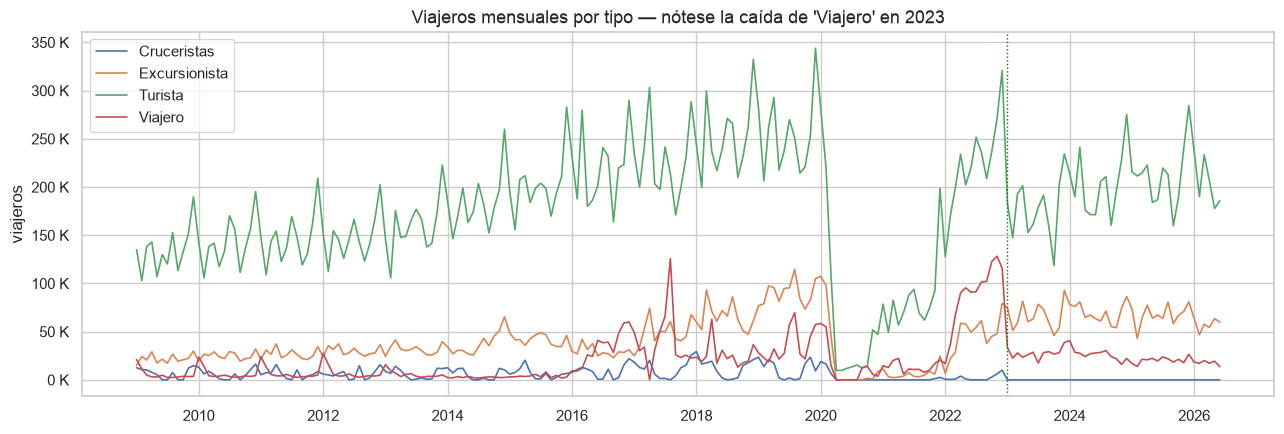

Total acumulado por tipo de viajero:
Tipo de Viajero
Turista         37,642,728.55
Excursionista    9,069,184.34
Viajero          4,471,622.21
Cruceristas      1,104,402.00
Name: Viajero, dtype: float64


In [11]:
comp = df.pivot_table(index="Fecha", columns="Tipo de Viajero",
                      values="Viajero", aggfunc="sum").fillna(0)

fig, ax = plt.subplots(figsize=(13, 4.5))
for col in comp.columns:
    ax.plot(comp.index, comp[col], label=col, lw=1.2)
ax.axvline(pd.Timestamp("2023-01-01"), color="green", ls=":", lw=1)
ax.set_title("Viajeros mensuales por tipo — nótese la caída de 'Viajero' en 2023")
ax.set_ylabel("viajeros"); ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f} K"))
plt.tight_layout(); plt.show()

# Aporte acumulado de cada tipo
print("Total acumulado por tipo de viajero:")
print(df.groupby("Tipo de Viajero")["Viajero"].sum().sort_values(ascending=False))

**Interpretación (tipo).** La curva de **"Viajero"** se desploma tras la línea de 2023 (verde) sin
que sea una caída real de turismo, mientras que **Turista** y **Excursionista** mantienen su patrón
estacional continuo. Esto confirma la decisión metodológica: la **serie total** del laboratorio se
define como `Turista + Excursionista`.

## 5. Países con mayor cantidad de viajeros

*(Requisito 1b.)* Ranking por **total acumulado** en todo el período (criterio que pide el
enunciado para elegir el Top-3, no un año específico).

Top 10 países / agrupaciones por viajeros acumulados:
País
El Salvador                 16,213,975.46
Guatemala                   14,792,331.35
Estados Unidos de América    7,047,842.96
Honduras                     2,788,232.82
México                       1,808,945.78
Belice                       1,328,255.77
Nicaragua                    1,164,342.73
Cruceristas                  1,078,372.00
Costa Rica                     882,179.75
Colombia                       561,035.32
Name: Viajero, dtype: float64


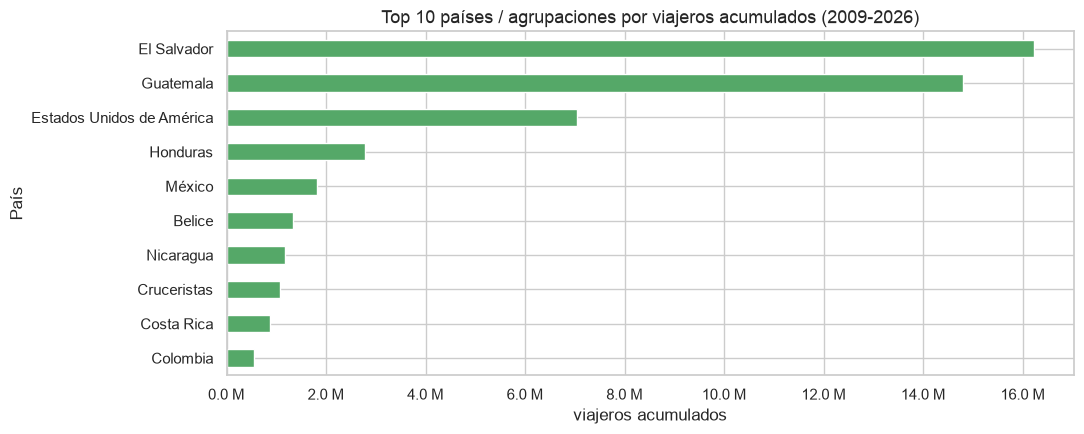

In [12]:
top_paises = (df.groupby("País")["Viajero"].sum()
                .sort_values(ascending=False))
print("Top 10 países / agrupaciones por viajeros acumulados:")
print(top_paises.head(10))

fig, ax = plt.subplots(figsize=(11, 4.5))
top_paises.head(10).iloc[::-1].plot(kind="barh", color="#55a868", ax=ax)
ax.set_title("Top 10 países / agrupaciones por viajeros acumulados (2009-2026)")
ax.set_xlabel("viajeros acumulados")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.1f} M"))
plt.tight_layout(); plt.show()

> **Nota** sobre el Top-3 de países: recuérdese el cambio de granularidad desde 2023 (país →
> agrupación de mercado). Los mercados grandes (El Salvador, EE. UU., Honduras, México…) siguen
> siendo comparables como serie; lo tendremos en cuenta al construir las series por país en la
> entrega final.

## 6. Regiones con mayor cantidad de viajeros

*(Requisito 1c.)* Usamos `Región dos` (continentes / grandes áreas), que es la variable que pide
el enunciado para la categoría de regiones geográficas.

Región dos
América Del Centro            37,406,534.83
América Del Norte              9,383,035.37
Europa                         2,222,620.85
América Del Sur y el Caribe    1,447,949.65
Cruceristas                    1,078,372.00
Asia                             421,702.52
Oceanía                          140,047.19
Oriente Medio                    135,712.55
Cruceros                          26,030.00
Otros Paises Del Mundo            25,111.15
0                                    821.00
Name: Viajero, dtype: float64


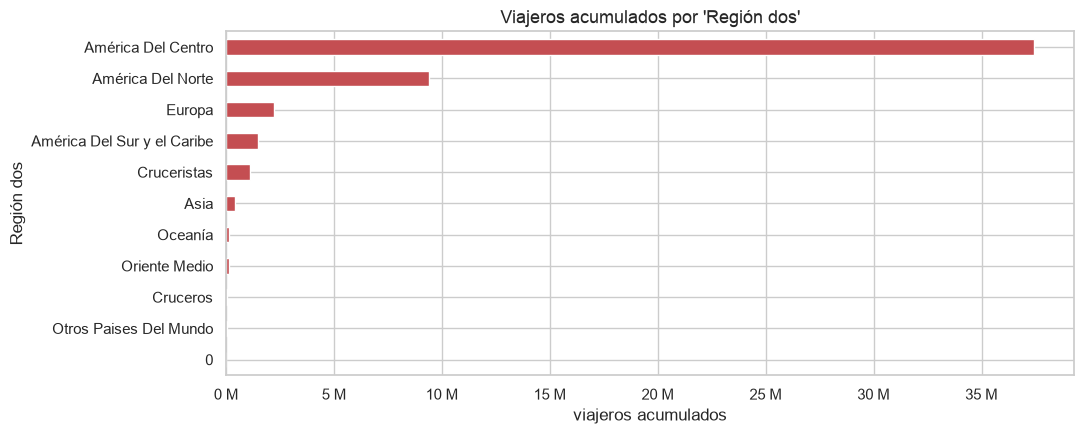

In [13]:
top_region = df.groupby("Región dos")["Viajero"].sum().sort_values(ascending=False)
print(top_region)

fig, ax = plt.subplots(figsize=(11, 4.5))
top_region.iloc[::-1].plot(kind="barh", color="#c44e52", ax=ax)
ax.set_title("Viajeros acumulados por 'Región dos'")
ax.set_xlabel("viajeros acumulados")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.0f} M"))
plt.tight_layout(); plt.show()

**Interpretación (regiones).** El mercado está **fuertemente concentrado en América**: *América
del Centro* domina por amplio margen (vecindad terrestre), seguida de *América del Norte* y
*Europa*. Este Top-3 sería la base de las series por región si se eligiera esa categoría.

## 7. Vías de ingreso y fronteras más utilizadas

*(Requisito 1d.)*

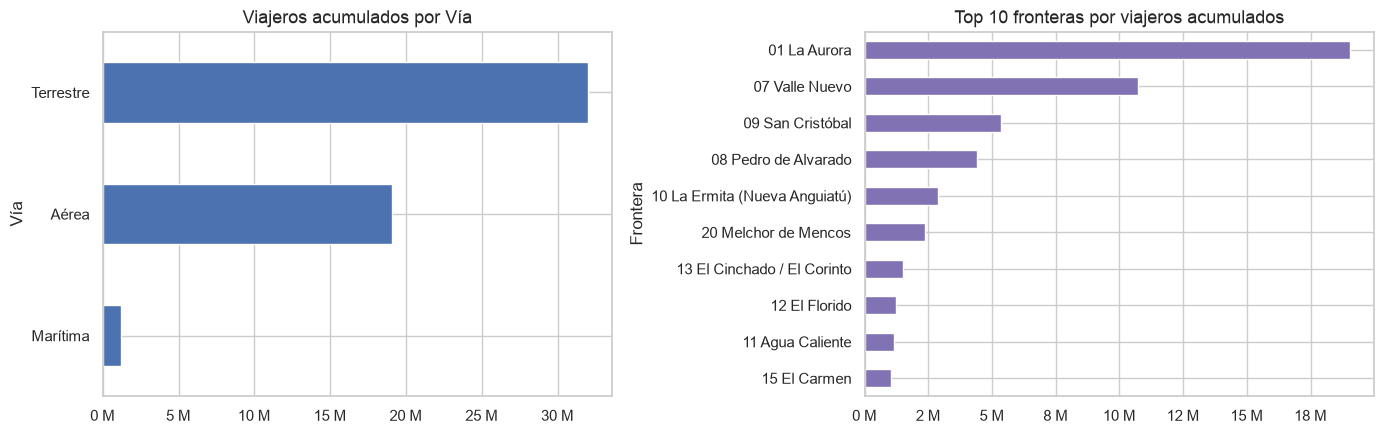

Participación por vía (%):
Vía
Terrestre   61.20
Aérea       36.50
Marítima     2.40
Name: Viajero, dtype: float64


In [14]:
via = df.groupby("Vía")["Viajero"].sum().sort_values(ascending=False)
frontera = df.groupby("Frontera")["Viajero"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
via.iloc[::-1].plot(kind="barh", color="#4c72b0", ax=ax[0])
ax[0].set_title("Viajeros acumulados por Vía")
ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.0f} M"))

frontera.head(10).iloc[::-1].plot(kind="barh", color="#8172b3", ax=ax[1])
ax[1].set_title("Top 10 fronteras por viajeros acumulados")
ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:,.0f} M"))
plt.tight_layout(); plt.show()

print("Participación por vía (%):")
print((via / via.sum() * 100).round(1))

**Interpretación (vías/fronteras).** La vía **Terrestre** concentra la mayor parte de los ingresos
(coherente con el peso de Centroamérica), seguida de la **Aérea** y, muy por detrás, la
**Marítima** (que además pierde detalle de registro desde 2017). Las fronteras terrestres con los
países vecinos y el aeropuerto La Aurora encabezan el ranking.

## 8. Patrón estacional y efecto de la pandemia

*(Requisito 1f y punto de la rúbrica: comportamiento durante y después de la pandemia.)*
Sobre la serie total consistente (`Turista + Excursionista`) vemos el patrón por mes y el impacto
de 2020.

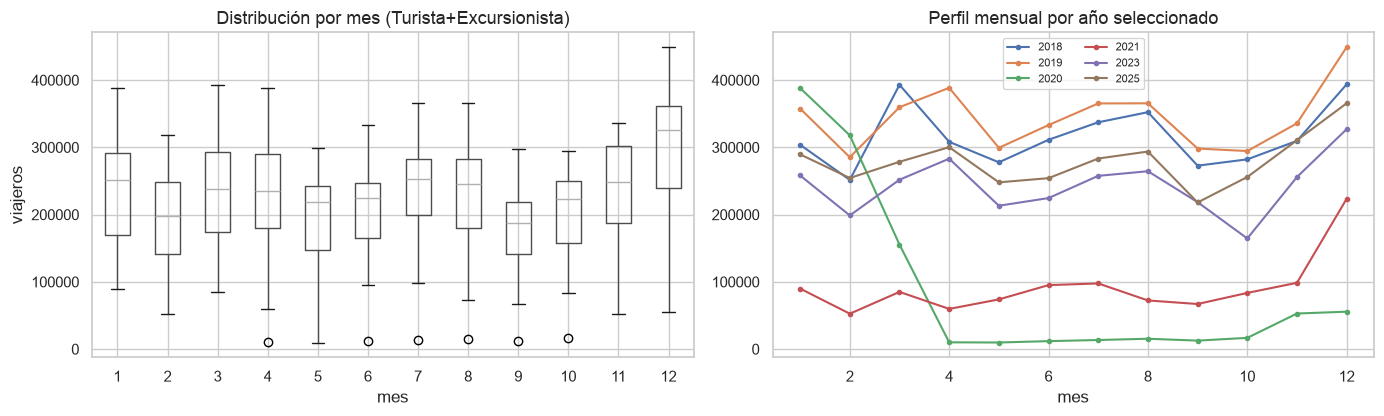

In [15]:
mask_te = df["Tipo de Viajero"].isin(["Turista", "Excursionista"])
serie_te = df[mask_te].groupby("Fecha")["Viajero"].sum()

tmp = serie_te.to_frame("v")
tmp["mes"] = tmp.index.month
tmp["anio"] = tmp.index.year

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
tmp.boxplot(column="v", by="mes", ax=ax[0])
ax[0].set_title("Distribución por mes (Turista+Excursionista)")
ax[0].set_xlabel("mes"); ax[0].set_ylabel("viajeros")

for anio in [2018, 2019, 2020, 2021, 2023, 2025]:
    sub = tmp[tmp["anio"] == anio]
    ax[1].plot(sub["mes"], sub["v"], marker=".", label=str(anio))
ax[1].set_title("Perfil mensual por año seleccionado")
ax[1].set_xlabel("mes"); ax[1].legend(ncol=2, fontsize=8)
plt.suptitle(""); plt.tight_layout(); plt.show()

In [16]:
# Cuantificamos el golpe de la pandemia: 2020-2021 vs 2019
base_2019 = serie_te[serie_te.index.year == 2019].sum()
for a in [2020, 2021, 2022, 2023]:
    tot = serie_te[serie_te.index.year == a].sum()
    print(f"{a}: {tot/base_2019*100:5.1f}% del nivel de 2019")

2020:  25.6% del nivel de 2019
2021:  26.6% del nivel de 2019
2022:  78.1% del nivel de 2019
2023:  70.6% del nivel de 2019


**Interpretación (estacionalidad + pandemia).** Existe un patrón estacional recurrente (meses altos
asociados a temporadas de viaje). La **pandemia** provocó una caída abrupta en 2020 hasta un piso
cercano a un cuarto del nivel de 2019, con recuperación progresiva en 2022–2023. Esto será clave
para el modelado: 2020–2021 es un tramo atípico que puede afectar tendencia y estacionalidad.

## 9. Resumen del EDA

- **Cobertura**: 210 meses consecutivos sin huecos (ene-2009 a jun-2026); 2026 es parcial.
- **Calidad**: sin nulos, sin duplicados, sin negativos; `Viajero` es una medida continua asimétrica.
- **Mercados**: fuerte concentración en América (Centro y Norte) y en la vía **Terrestre**.
- **Quiebres a tener presentes**: pandemia (2020), quiebre metodológico 2023 (→ usar
  `Turista+Excursionista`), cambio de granularidad de `País` desde 2023, y pérdida de detalle de la
  vía Marítima desde 2017.

Con esto pasamos al **análisis preliminar de dos series de tiempo**.

# Parte II — Análisis preliminar de dos series de tiempo

En esta parte del avance construimos y analizamos **dos** series mensuales:

1. **Total de viajeros internacionales** — definida como `Turista + Excursionista` (la versión
   consistente en todo el período, justificada en la Parte I).
2. **Vía de ingreso Aérea** — también restringida a `Turista + Excursionista`, para que sea
   comparable con la serie total y no arrastre el quiebre metodológico de la categoría "Viajero".

Para cada serie seguimos el guion del ejercicio 4: (a) inicio, fin y frecuencia; (b) gráfico e
interpretación a primera vista; y en los siguientes commits, descomposición, estacionariedad y
selección de parámetros.

## 10. Construcción de las series mensuales

*(Requisito 3: agregación mensual a partir de la categoría correspondiente.)* Partimos siempre del
mismo filtro `Turista + Excursionista` y agregamos con `sum` a nivel mensual. El índice queda con
frecuencia mensual `MS` (inicio de mes), sin huecos.

In [17]:
# Filtro base consistente en todo el período
base = df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])]

# Serie 1: Total mensual de viajeros internacionales
serie_total = base.groupby("Fecha")["Viajero"].sum().sort_index()
serie_total = serie_total.asfreq("MS")          # fija la frecuencia mensual explícitamente
serie_total.name = "Total (Turista+Excursionista)"

# Serie 2: Vía de ingreso Aérea
serie_aerea = (base[base["Vía"] == "Aérea"]
               .groupby("Fecha")["Viajero"].sum().sort_index())
serie_aerea = serie_aerea.asfreq("MS")
serie_aerea.name = "Vía Aérea (Turista+Excursionista)"

print("Longitud serie_total:", len(serie_total), "| NaNs:", serie_total.isna().sum())
print("Longitud serie_aerea:", len(serie_aerea), "| NaNs:", serie_aerea.isna().sum())
serie_total.head()

Longitud serie_total: 210 | NaNs: 0
Longitud serie_aerea: 210 | NaNs: 0


Fecha
2009-01-01   149,944.03
2009-02-01   127,303.69
2009-03-01   158,795.67
2009-04-01   172,013.47
2009-05-01   124,559.52
Freq: MS, Name: Total (Turista+Excursionista), dtype: float64

### 10.1 Inicio, fin y frecuencia

*(Requisito 4a.)*

In [18]:
def resumen_serie(s):
    return pd.Series({
        "Inicio": s.index.min().strftime("%Y-%m"),
        "Fin": s.index.max().strftime("%Y-%m"),
        "Frecuencia": s.index.freqstr,
        "N observaciones": len(s),
        "Media": s.mean(),
        "Mínimo": s.min(),
        "Máximo": s.max(),
    })

resumen = pd.DataFrame({
    serie_total.name: resumen_serie(serie_total),
    serie_aerea.name: resumen_serie(serie_aerea),
})
resumen

,Total (Turista+Excursionista),Vía Aérea (Turista+Excursionista)
Inicio,2009-01,2009-01
Fin,2026-06,2026-06
Frecuencia,MS,MS
N observaciones,210,210
Media,"222,437.68","90,568.66"
Mínimo,"9,779.00",489.00
Máximo,"449,114.07","158,463.00"


Ambas series son **mensuales (`MS`)**, van de **enero-2009 a junio-2026** (210 observaciones,
sin huecos). Recuérdese que **2026 es parcial** (solo enero–junio): se conserva porque son datos
mensuales reales y válidos, pero se tendrá presente al interpretar el último tramo.

### 10.2 Gráfico de cada serie e interpretación a primera vista

*(Requisito 4b.)*

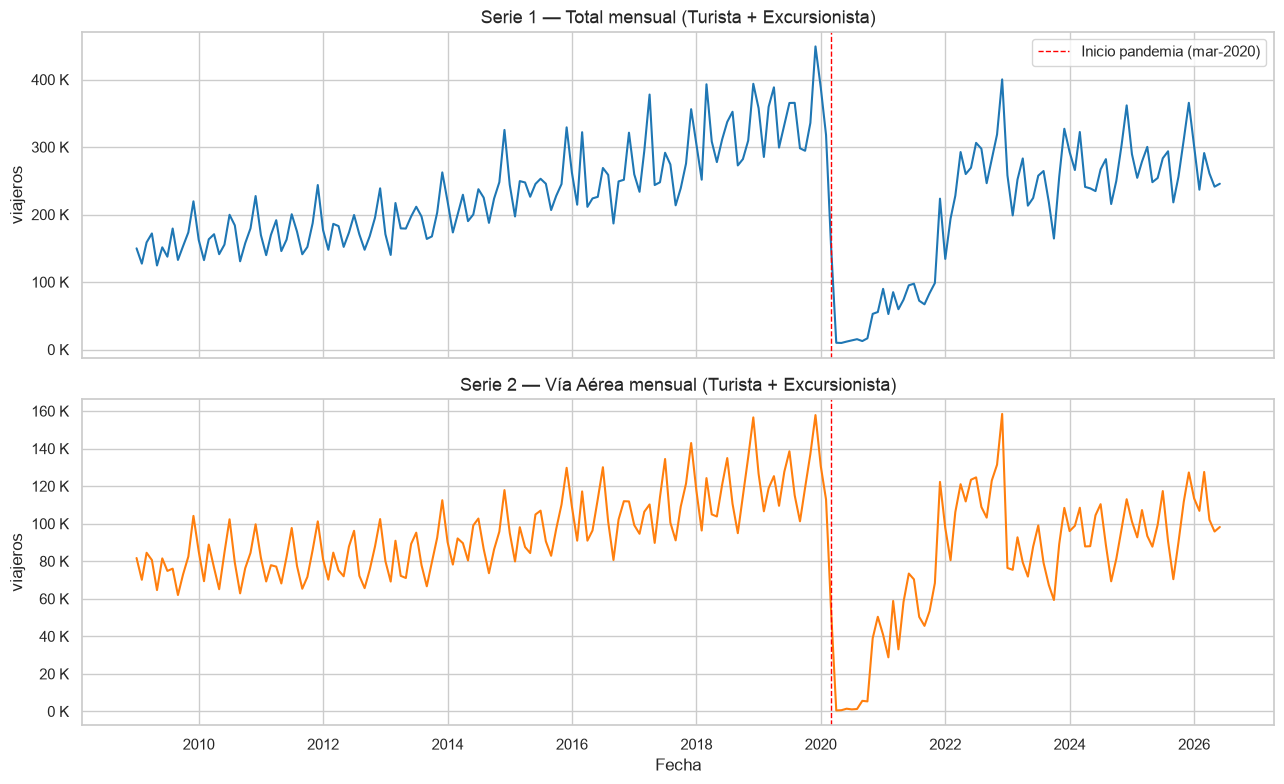

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax[0].plot(serie_total.index, serie_total.values, color="#1f77b4")
ax[0].axvline(pd.Timestamp("2020-03-01"), color="red", ls="--", lw=1,
              label="Inicio pandemia (mar-2020)")
ax[0].set_title("Serie 1 — Total mensual (Turista + Excursionista)")
ax[0].set_ylabel("viajeros"); ax[0].legend()
ax[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f} K"))

ax[1].plot(serie_aerea.index, serie_aerea.values, color="#ff7f0e")
ax[1].axvline(pd.Timestamp("2020-03-01"), color="red", ls="--", lw=1)
ax[1].set_title("Serie 2 — Vía Aérea mensual (Turista + Excursionista)")
ax[1].set_xlabel("Fecha"); ax[1].set_ylabel("viajeros")
ax[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f} K"))

plt.tight_layout(); plt.show()

**Interpretación a primera vista.**

- **Serie Total.** Muestra un nivel con **tendencia creciente** de fondo (2009–2019), una
  **estacionalidad anual** marcada y el **colapso abrupto de mar-2020** por la pandemia, seguido de
  una recuperación que retoma —e incluso supera— los niveles previos hacia 2023–2025. La amplitud
  de las oscilaciones estacionales parece **crecer con el nivel** de la serie (indicio de
  estacionalidad *multiplicativa* → posible necesidad de transformación logarítmica, que se analiza
  en el siguiente commit).

- **Serie Vía Aérea.** Comparte la misma estructura (tendencia + estacionalidad + shock de 2020),
  pero con **menor volatilidad relativa** y un piso pandémico aún más profundo (el cierre de
  aeropuertos golpeó más a la vía aérea que a la terrestre). Su recuperación posterior es clara y
  sostenida.

En ambas, el tramo **2020–2021 es atípico** y deberá tenerse en cuenta al descomponer y modelar.

## 11. Descomposición y estacionariedad en varianza

*(Requisitos 4c y 4d.)* Separamos cada serie en **tendencia + estacionalidad + residuo** para
discutir si puede hablarse de estacionariedad en **media** y en **varianza**, y decidir si es
necesaria una **transformación**. Comparamos el modelo **aditivo** (componentes que se suman,
estacionalidad de amplitud constante) con el **multiplicativo** (componentes que se multiplican,
estacionalidad cuya amplitud crece con el nivel).

In [20]:
def comparar_descomposicion(s, titulo):
    desc_add = seasonal_decompose(s, model="additive", period=12)
    desc_mul = seasonal_decompose(s, model="multiplicative", period=12)

    fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)
    for j, (desc, nombre) in enumerate([(desc_add, "Aditiva"), (desc_mul, "Multiplicativa")]):
        axes[0, j].plot(s, color="#333"); axes[0, j].set_title(f"{titulo} — {nombre}")
        axes[1, j].plot(desc.trend, color="#1f77b4"); axes[1, j].set_ylabel("tendencia")
        axes[2, j].plot(desc.seasonal, color="#2ca02c"); axes[2, j].set_ylabel("estacional")
        axes[3, j].plot(desc.resid, color="#d62728", marker=".", ls="none", ms=3)
        axes[3, j].set_ylabel("residuo")
    plt.tight_layout(); plt.show()

    # Indicador cuantitativo: variabilidad del residuo (coef. de variación)
    cv_add = np.nanstd(desc_add.resid)
    cv_mul = np.nanstd(desc_mul.resid)
    print(f"Desv. estándar del residuo -> Aditiva: {cv_add:,.1f} | "
          f"Multiplicativa: {cv_mul:.4f} (residuo multiplicativo ~1, adimensional)")
    return desc_add, desc_mul

### 11.1 Serie Total

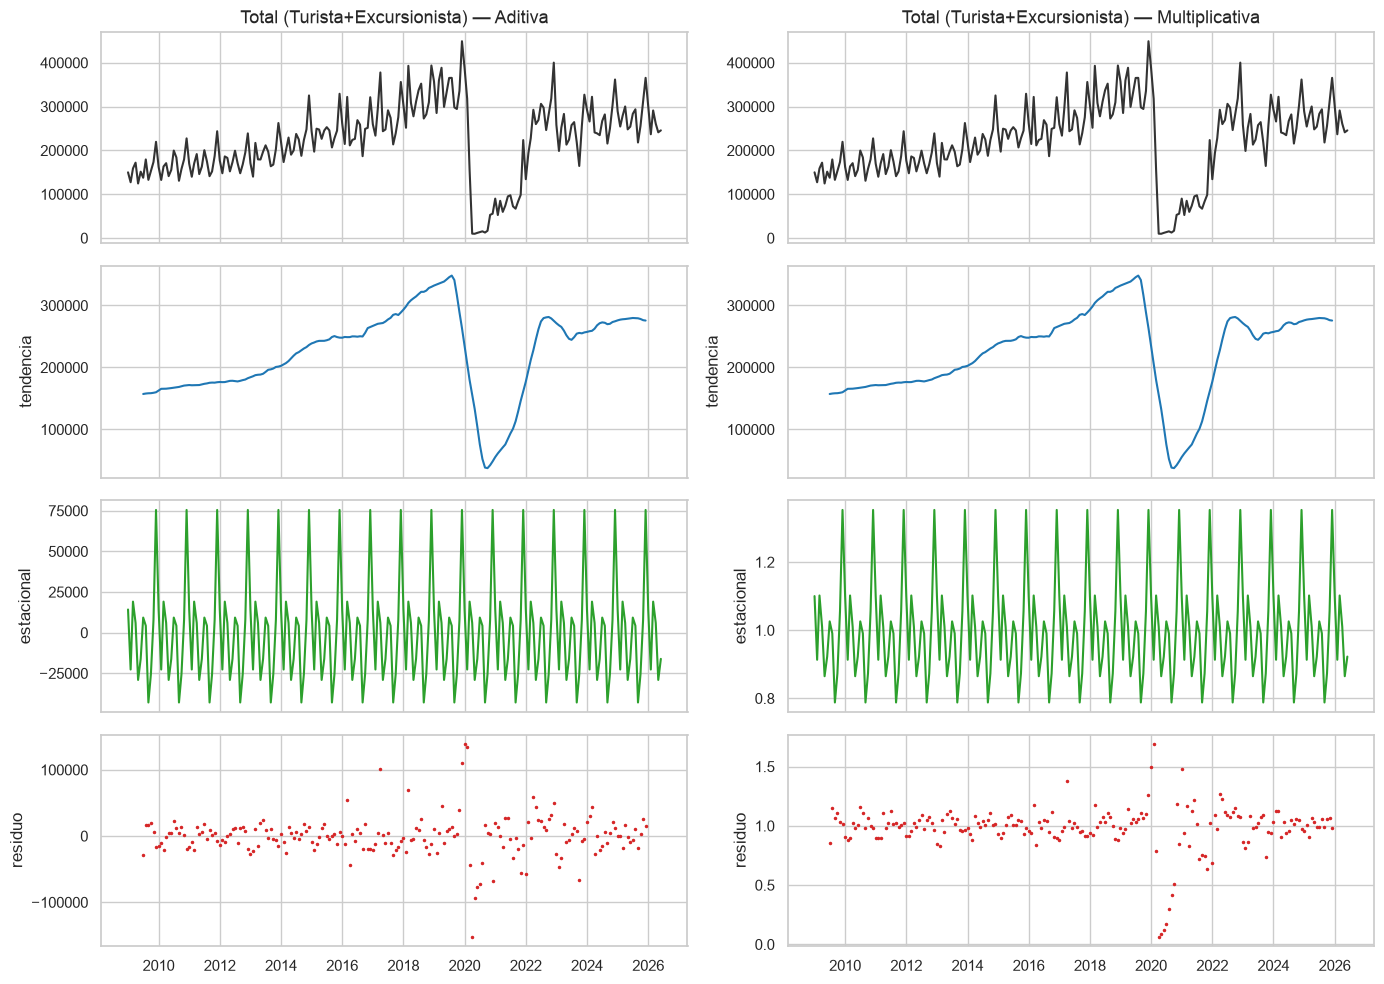

Desv. estándar del residuo -> Aditiva: 30,493.6 | Multiplicativa: 0.1906 (residuo multiplicativo ~1, adimensional)


In [21]:
_ = comparar_descomposicion(serie_total, "Total (Turista+Excursionista)")

**Interpretación (Total).**
- **Tendencia:** claramente **creciente** hasta 2019, hundimiento en 2020 (pandemia) y recuperación
  posterior. La media **cambia con el tiempo** → la serie **no es estacionaria en media**.
- **Estacionalidad:** patrón anual estable y repetido (período 12).
- **Varianza:** en la descomposición **aditiva** el residuo es más grande cuando el nivel de la
  serie es mayor (embudo), mientras que en la **multiplicativa** el residuo queda mucho más
  homogéneo alrededor de 1. Esto indica que **la amplitud estacional crece con el nivel** →
  estacionalidad *multiplicativa* → **no estacionaria en varianza**.

### 11.2 Serie Vía Aérea

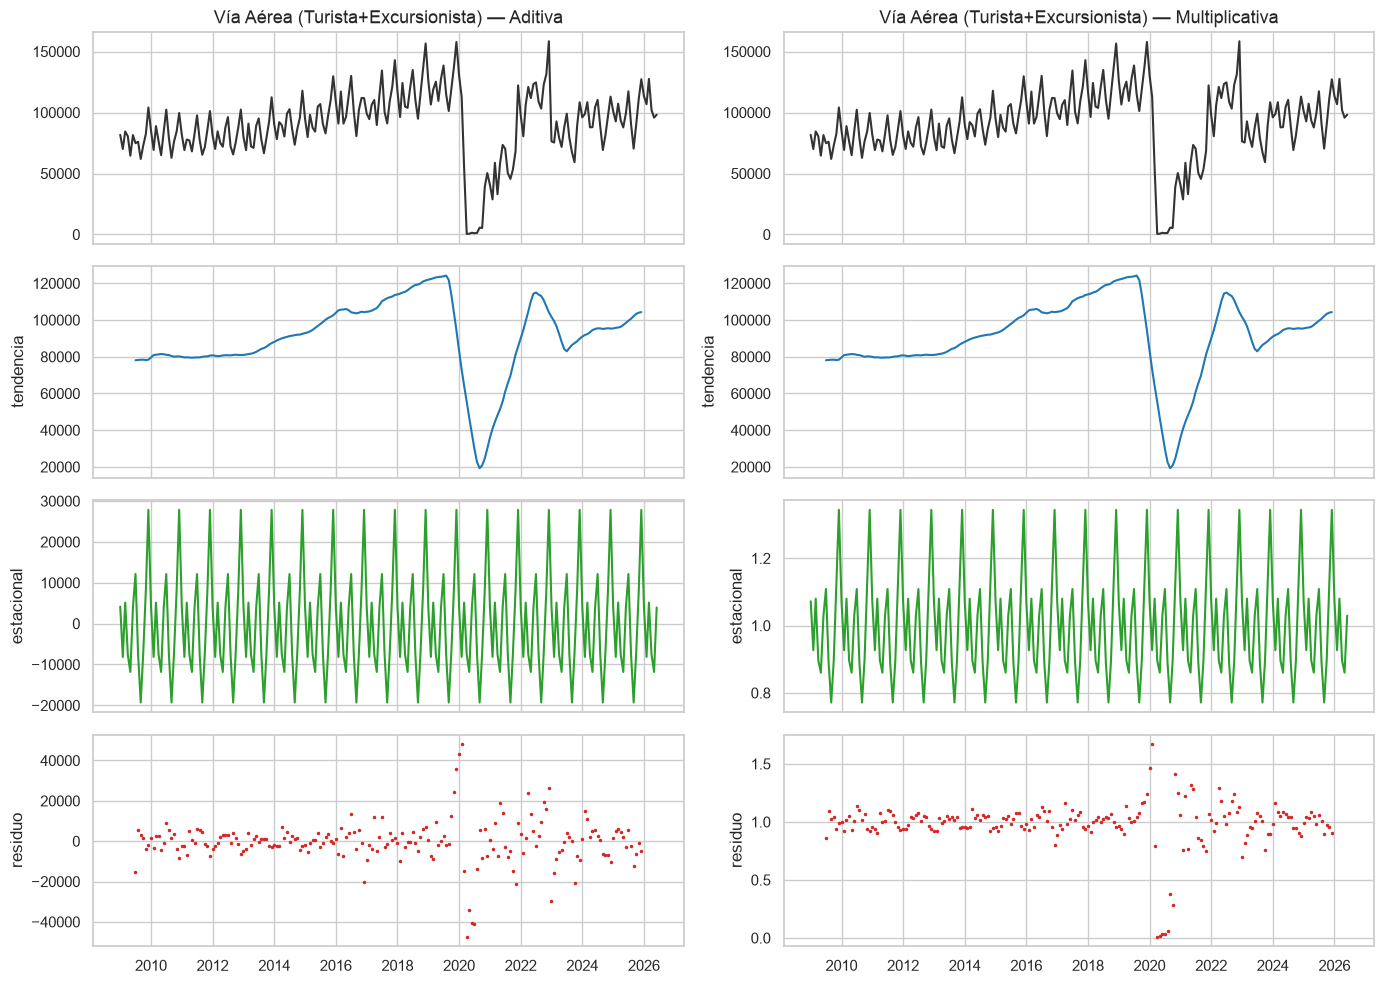

Desv. estándar del residuo -> Aditiva: 10,819.8 | Multiplicativa: 0.2032 (residuo multiplicativo ~1, adimensional)


In [22]:
_ = comparar_descomposicion(serie_aerea, "Vía Aérea (Turista+Excursionista)")

**Interpretación (Vía Aérea).** Mismo diagnóstico: tendencia creciente (no estacionaria en media),
estacionalidad anual marcada y residuo aditivo que se ensancha con el nivel (no estacionaria en
varianza). El shock de 2020 es aún más pronunciado.

### 11.3 Estacionariedad en varianza: media y desviación móviles

*(Requisito 4d.)* Si la **desviación estándar móvil** cambia con el tiempo (típicamente crece con
el nivel), la serie **no es estacionaria en varianza** y conviene transformarla. Usamos una ventana
de 12 meses.

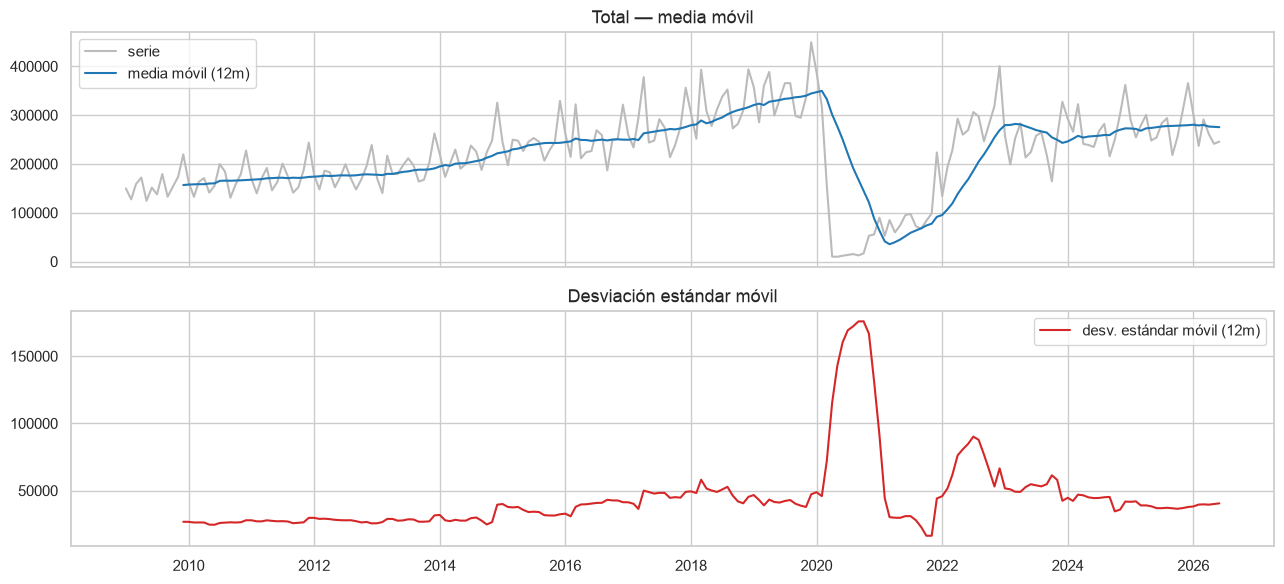

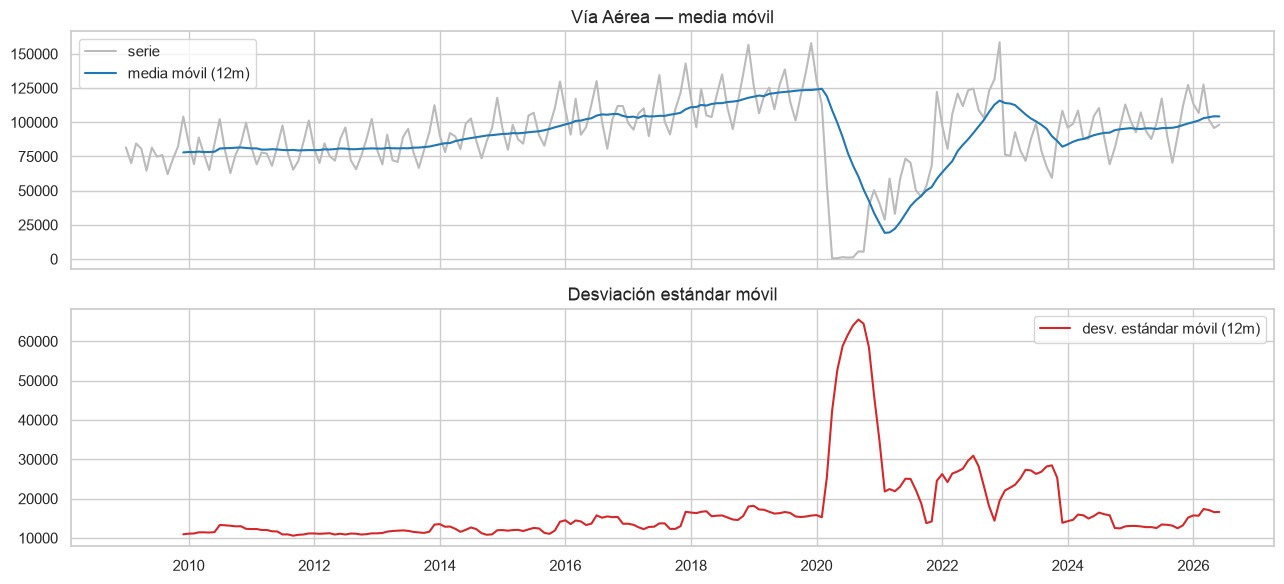

In [23]:
def media_std_movil(s, titulo, ventana=12):
    media_m = s.rolling(ventana).mean()
    std_m = s.rolling(ventana).std()
    fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    ax[0].plot(s, color="#bbb", label="serie")
    ax[0].plot(media_m, color="#1f77b4", label=f"media móvil ({ventana}m)")
    ax[0].set_title(f"{titulo} — media móvil"); ax[0].legend()
    ax[1].plot(std_m, color="#d62728", label=f"desv. estándar móvil ({ventana}m)")
    ax[1].set_title("Desviación estándar móvil"); ax[1].legend()
    plt.tight_layout(); plt.show()

media_std_movil(serie_total, "Total")
media_std_movil(serie_aerea, "Vía Aérea")

**Interpretación.** Tanto la media como la desviación estándar móviles **suben y bajan con el nivel**
de la serie (crecen hasta 2019, se desploman en 2020, se recuperan después). La desviación no es
constante → **confirmamos la no estacionariedad en varianza**. La transformación estándar para
estabilizarla es el **logaritmo**.

### 11.4 Transformación logarítmica

Aplicamos `log` (ambas series son estrictamente positivas, así que es válido) y verificamos que la
varianza se estabiliza. Trabajaremos con la serie en escala log para el modelado, invirtiendo con
`exp` al evaluar.

Mínimos (deben ser > 0 para poder aplicar log):
  serie_total: 9,779.0
  serie_aerea: 489.0


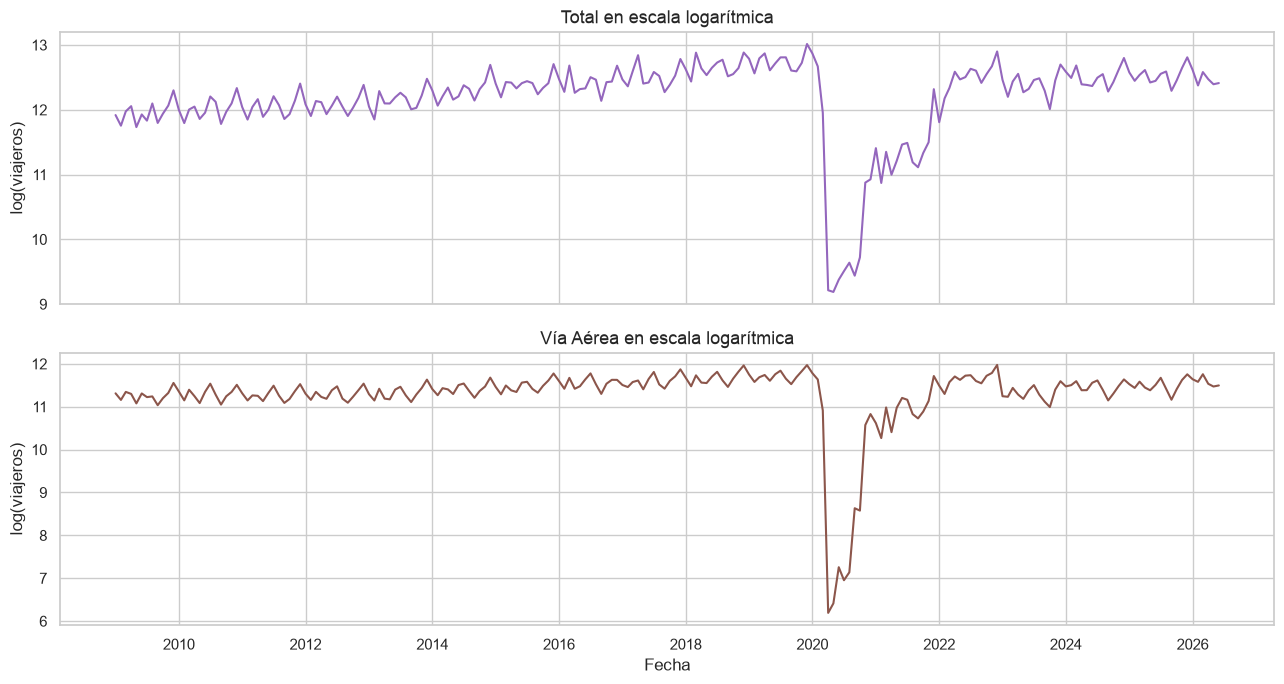


Correlación nivel (media móvil 12m) vs dispersión (std móvil 12m)
Ventana PRE-PANDEMIA 2009-2019 (alta y positiva = varianza depende del nivel):

  Total : escala original = +0.85  ->  escala log = -0.22
  Aérea : escala original = +0.87  ->  escala log = -0.32


In [24]:
print("Mínimos (deben ser > 0 para poder aplicar log):")
print(f"  serie_total: {serie_total.min():,.1f}")
print(f"  serie_aerea: {serie_aerea.min():,.1f}")

serie_total_log = np.log(serie_total)
serie_aerea_log = np.log(serie_aerea)

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(serie_total_log, color="#9467bd")
ax[0].set_title("Total en escala logarítmica"); ax[0].set_ylabel("log(viajeros)")
ax[1].plot(serie_aerea_log, color="#8c564b")
ax[1].set_title("Vía Aérea en escala logarítmica"); ax[1].set_ylabel("log(viajeros)")
ax[1].set_xlabel("Fecha")
plt.tight_layout(); plt.show()

# Diagnóstico de varianza multiplicativa: relación nivel–dispersión.
# Si la dispersión crece con el nivel, la CORRELACIÓN entre la media móvil (nivel) y la
# desviación estándar móvil (dispersión) es alta y positiva. Una buena transformación de
# varianza (el log) debe REDUCIR esa correlación.
#
# IMPORTANTE: lo medimos en la ventana PRE-PANDEMIA (2009-2019). Sobre la serie completa el
# quiebre estructural de 2020 (dispersión alta coincidiendo con nivel bajo) contamina el
# estadístico y lo vuelve engañoso; sin ese quiebre, la relación multiplicativa se ve limpia.
print("\nCorrelación nivel (media móvil 12m) vs dispersión (std móvil 12m)")
print("Ventana PRE-PANDEMIA 2009-2019 (alta y positiva = varianza depende del nivel):\n")
for nombre, s in [("Total", serie_total), ("Aérea", serie_aerea)]:
    pre = s[s.index < "2020-01-01"]
    m_o, d_o = pre.rolling(12).mean(), pre.rolling(12).std()
    m_l, d_l = np.log(pre).rolling(12).mean(), np.log(pre).rolling(12).std()
    print(f"  {nombre:6s}: escala original = {m_o.corr(d_o):+.2f}  ->  escala log = {m_l.corr(d_l):+.2f}")

**Conclusión (transformación).** La evidencia apunta a **varianza multiplicativa**: en el período
pre-pandemia (sin quiebre estructural) la dispersión crece con el nivel (correlación nivel–dispersión
≈ **+0.85 / +0.87**), y al aplicar `log` esa dependencia **desaparece** (correlación cae a valores
cercanos a 0 o negativos). Visualmente, en escala logarítmica la amplitud de las oscilaciones se
vuelve **aproximadamente constante**. Por tanto, **sí es necesario transformar** ambas series, y
usaremos la **escala logarítmica** de aquí en adelante (invirtiendo con `exp` al evaluar).

Dos matices honestos: (1) el `log` **no** elimina la tendencia ni la estacionalidad —la serie sigue
siendo **no estacionaria en media**, lo que se aborda con diferenciación en el siguiente commit
(ADF y ACF); y (2) la **pandemia de 2020 es un quiebre estructural atípico** que ninguna
transformación simple corrige del todo, y habrá que tenerlo presente al modelar.

## 12. Estacionariedad en media: autocorrelación y prueba de Dickey-Fuller

*(Requisito 4e.)* Ya estabilizamos la varianza con el `log`. Ahora estudiamos la estacionariedad
**en media**. Una serie con tendencia **no** es estacionaria en media: su ACF decae muy lentamente y
la prueba **ADF** (Dickey-Fuller aumentada) no rechaza la hipótesis de raíz unitaria. La usamos
junto con **KPSS** (hipótesis contraria) para un diagnóstico robusto, y determinamos cuántas
**diferenciaciones** `d` hacen falta.

In [25]:
def prueba_adf(x, nombre=""):
    r = adfuller(x.dropna(), autolag="AIC")
    veredicto = "ESTACIONARIA" if r[1] < 0.05 else "NO estacionaria"
    print(f"ADF  {nombre:32s} estad={r[0]:7.3f}  p-valor={r[1]:.4f}  -> {veredicto}")
    return r[1]

def prueba_kpss(x, nombre=""):
    stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")
    # En KPSS la H0 es 'estacionaria': p pequeño -> NO estacionaria
    veredicto = "NO estacionaria" if p < 0.05 else "ESTACIONARIA"
    print(f"KPSS {nombre:32s} estad={stat:7.3f}  p-valor={p:.4f}  -> {veredicto}")
    return p

print("=== Series en escala log (nivel), antes de diferenciar ===")
for s, nom in [(serie_total_log, "Total (log)"), (serie_aerea_log, "Aérea (log)")]:
    prueba_adf(s, nom); prueba_kpss(s, nom); print()

=== Series en escala log (nivel), antes de diferenciar ===
ADF  Total (log)                      estad= -2.649  p-valor=0.0833  -> NO estacionaria
KPSS Total (log)                      estad=  0.108  p-valor=0.1000  -> ESTACIONARIA

ADF  Aérea (log)                      estad= -3.523  p-valor=0.0074  -> ESTACIONARIA
KPSS Aérea (log)                      estad=  0.092  p-valor=0.1000  -> ESTACIONARIA



/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_81875/821220324.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")
/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_81875/821220324.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")


### 12.1 Autocorrelación (ACF y PACF) de la serie en nivel

*(Requisito 4e.i.)* Si la ACF decae **muy lentamente** (muchos rezagos significativos y positivos),
es señal visual de **no estacionariedad en media**.

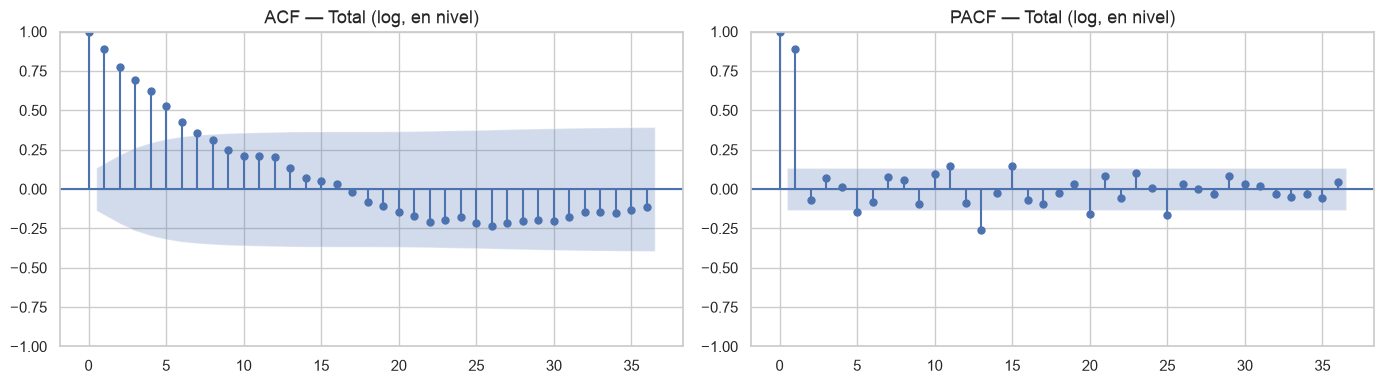

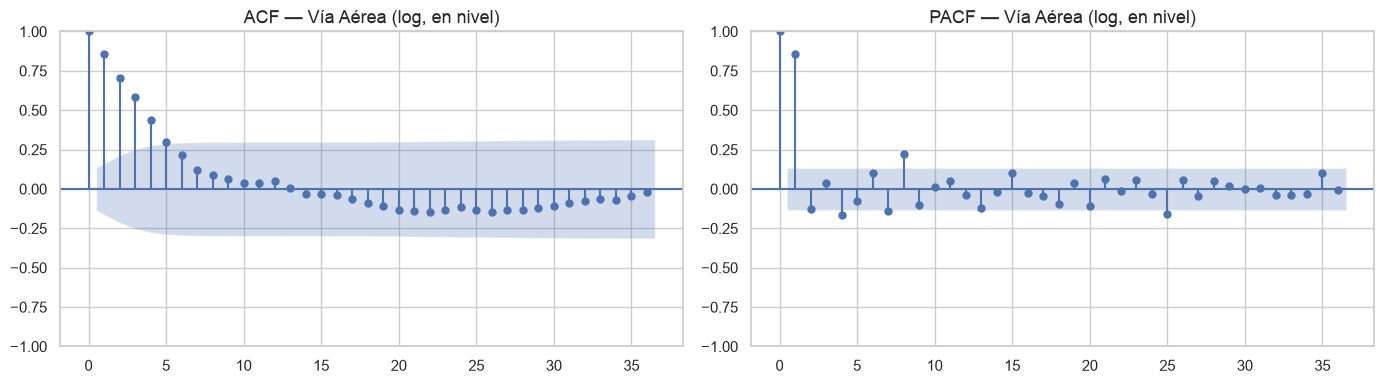

In [26]:
def acf_pacf(s, titulo, lags=36):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(s.dropna(), lags=lags, ax=ax[0]); ax[0].set_title(f"ACF — {titulo}")
    plot_pacf(s.dropna(), lags=lags, ax=ax[1], method="ywm"); ax[1].set_title(f"PACF — {titulo}")
    plt.tight_layout(); plt.show()

acf_pacf(serie_total_log, "Total (log, en nivel)")
acf_pacf(serie_aerea_log, "Vía Aérea (log, en nivel)")

**Interpretación (nivel).** La ACF de ambas series decae con lentitud y muestra **picos que
reaparecen en el rezago 12** (estacionalidad anual), señal de estructura persistente. Sin embargo,
las pruebas formales en nivel son **ambiguas**:

- **Total (log):** ADF en el **límite** (p ≈ 0.08, no rechaza raíz unitaria) mientras KPSS **no**
  rechaza estacionariedad → caso fronterizo.
- **Vía Aérea (log):** el ADF **sí rechaza** (p ≈ 0.007), sugiriendo estacionariedad pese a la
  tendencia visible.

Esta aparente contradicción es esperable: el ADF estándar se **distorsiona con la fuerte
estacionalidad y el quiebre estructural de la pandemia** (la caída y recuperación se leen como
reversión a la media). Por eso, para el **modelado ARIMA** no nos quedamos con la prueba en nivel:
dado que la descomposición evidencia tendencia y la ACF no decae a cero, aplicamos una diferencia
regular y comprobamos si el diagnóstico se vuelve **inequívoco**.

### 12.2 Diferenciación regular (d = 1)

*(Requisito 4e.ii.)* Aplicamos una diferencia regular de orden 1 sobre la serie en log
(`diff(1)`), que elimina la tendencia, y volvemos a evaluar.

=== Series log tras UNA diferencia regular (d=1) ===
ADF  Total (log, d=1)                 estad= -4.698  p-valor=0.0001  -> ESTACIONARIA
KPSS Total (log, d=1)                 estad=  0.029  p-valor=0.1000  -> ESTACIONARIA

ADF  Aérea (log, d=1)                 estad= -7.748  p-valor=0.0000  -> ESTACIONARIA
KPSS Aérea (log, d=1)                 estad=  0.017  p-valor=0.1000  -> ESTACIONARIA



/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_81875/821220324.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")
/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_81875/821220324.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")


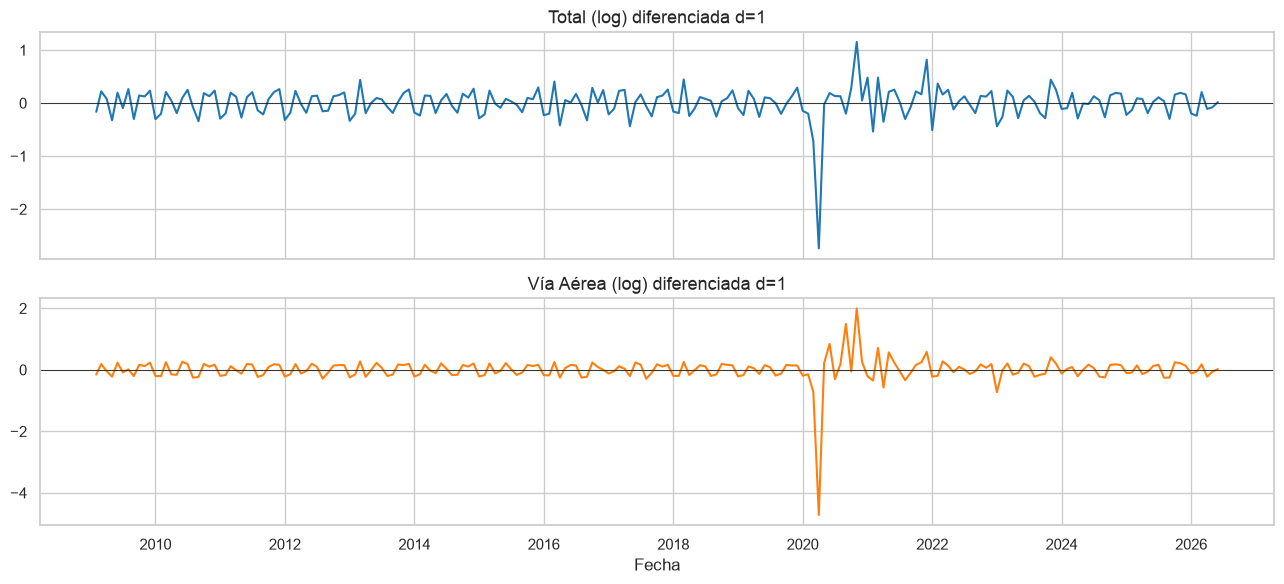

In [27]:
serie_total_d1 = serie_total_log.diff(1).dropna()
serie_aerea_d1 = serie_aerea_log.diff(1).dropna()

print("=== Series log tras UNA diferencia regular (d=1) ===")
for s, nom in [(serie_total_d1, "Total (log, d=1)"), (serie_aerea_d1, "Aérea (log, d=1)")]:
    prueba_adf(s, nom); prueba_kpss(s, nom); print()

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(serie_total_d1, color="#1f77b4"); ax[0].axhline(0, color="k", lw=.6)
ax[0].set_title("Total (log) diferenciada d=1")
ax[1].plot(serie_aerea_d1, color="#ff7f0e"); ax[1].axhline(0, color="k", lw=.6)
ax[1].set_title("Vía Aérea (log) diferenciada d=1"); ax[1].set_xlabel("Fecha")
plt.tight_layout(); plt.show()

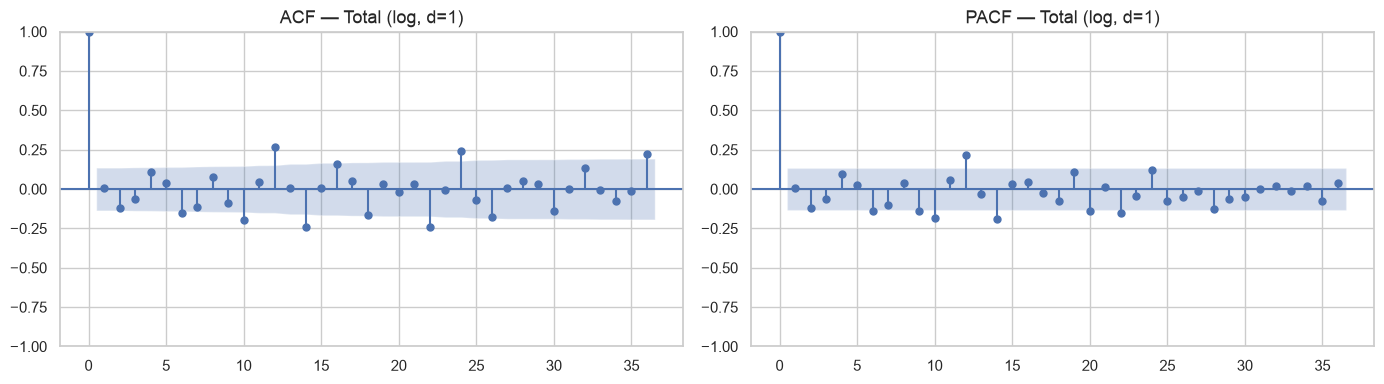

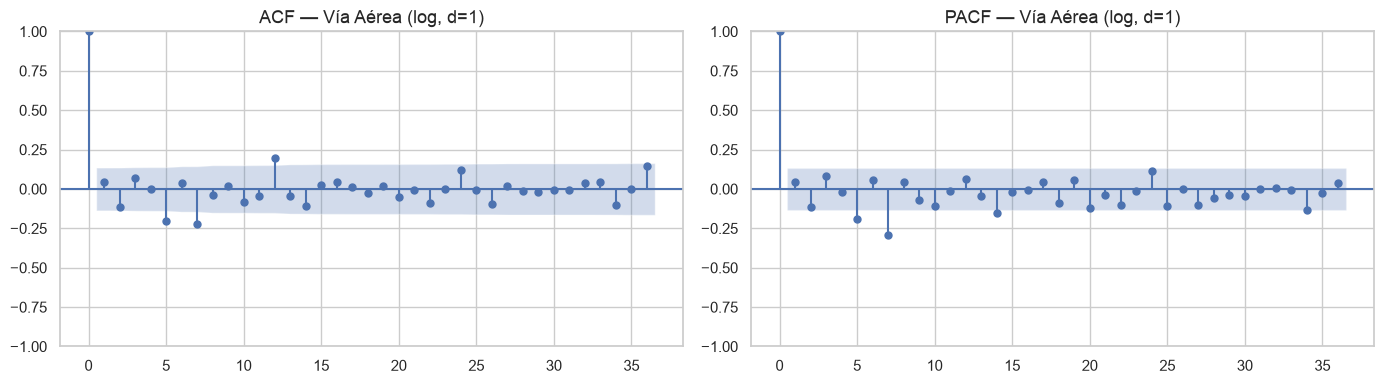

In [28]:
# ACF/PACF de las series ya diferenciadas -> sirven para proponer p y q en el siguiente commit
acf_pacf(serie_total_d1, "Total (log, d=1)")
acf_pacf(serie_aerea_d1, "Vía Aérea (log, d=1)")

**Interpretación (diferenciada).** Tras **una** diferencia regular el diagnóstico se vuelve
**inequívoco**: ambas series oscilan alrededor de media ~0, el **ADF rechaza con claridad** la raíz
unitaria (p < 0.001) y el **KPSS no rechaza** estacionariedad. Es decir, `d = 1` deja la media
estacionaria sin ambigüedad. En la ACF/PACF diferenciada **persisten picos en los rezagos
estacionales (≈12)**, lo que anticipa la necesidad de una **componente estacional** (diferenciación
estacional `D=1` y términos `P`,`Q`) → modelos **SARIMA** en la fase de modelado.

**Conclusión de estacionariedad.** Aunque las pruebas en nivel eran ambiguas (por la estacionalidad
y el quiebre pandémico), la evidencia conjunta —tendencia en la descomposición, ACF sin decaimiento
a cero, y el hecho de que `d = 1` produce estacionariedad inequívoca— justifica modelar con
**transformación log** (varianza) + **una diferenciación regular `d = 1`** (media), dejando la
**estacionalidad de período 12** para el componente SARIMA.

# Parte III — Series de las vías Terrestre y Marítima

Para completar la categoría **Vías de ingreso** construimos y analizamos las dos series restantes.
Cada una tiene una particularidad de datos que documentamos:

- **Terrestre** (`Turista + Excursionista`): serie limpia y completa 2009–jun 2026, igual criterio
  que la Aérea y la Total.
- **Marítima**: la vía marítima **pierde el detalle de Turista/Excursionista desde 2017**, por lo
  que ese criterio la truncaría en 2016. El flujo marítimo real son los **cruceros**
  (*Cruceristas*), disponibles de forma continua **2009–2022** (desde 2023 los cruceros se miden por
  fuente portuaria externa y no figuran). Por eso la serie Marítima se construye con **Cruceristas,
  ventana 2009-2022**.

## 13. Construcción de las series Terrestre y Marítima

In [29]:
# --- Terrestre: Turista + Excursionista, rango completo ---
serie_terrestre = (base[base["Vía"] == "Terrestre"]
                   .groupby("Fecha")["Viajero"].sum().sort_index().asfreq("MS"))
serie_terrestre.name = "Vía Terrestre (Turista+Excursionista)"

# --- Marítima: Cruceristas, ventana 2009-2022 ---
rango_mar = pd.date_range("2009-01-01", "2022-12-01", freq="MS")
serie_maritima = (df[(df["Vía"] == "Marítima") & (df["Tipo de Viajero"] == "Cruceristas")]
                  .groupby("Fecha")["Viajero"].sum().reindex(rango_mar))
n_ceros_mar = serie_maritima.isna().sum()
serie_maritima = serie_maritima.fillna(0.0).asfreq("MS")   # meses sin cruceros = 0
serie_maritima.name = "Vía Marítima (Cruceristas)"

print(f"Terrestre: n={len(serie_terrestre)}  NaN={serie_terrestre.isna().sum()}  min={serie_terrestre.min():,.0f}")
print(f"Marítima : n={len(serie_maritima)}  meses en 0={int((serie_maritima==0).sum())}  "
      f"(temporada baja de cruceros + cierre pandémico)")

Terrestre: n=210  NaN=0  min=5,240
Marítima : n=168  meses en 0=45  (temporada baja de cruceros + cierre pandémico)


### 13.1 Inicio, fin y frecuencia *(Req. 4a)*

In [30]:
pd.DataFrame({
    serie_terrestre.name: resumen_serie(serie_terrestre),
    serie_maritima.name: resumen_serie(serie_maritima),
})

,Vía Terrestre (Turista+Excursionista),Vía Marítima (Cruceristas)
Inicio,2009-01,2009-01
Fin,2026-06,2022-12
Frecuencia,MS,MS
N observaciones,210,168
Media,"131,391.68","6,573.82"
Mínimo,"5,240.00",0.00
Máximo,"291,272.07","29,506.00"


### 13.2 Gráfico de las series *(Req. 4b)*

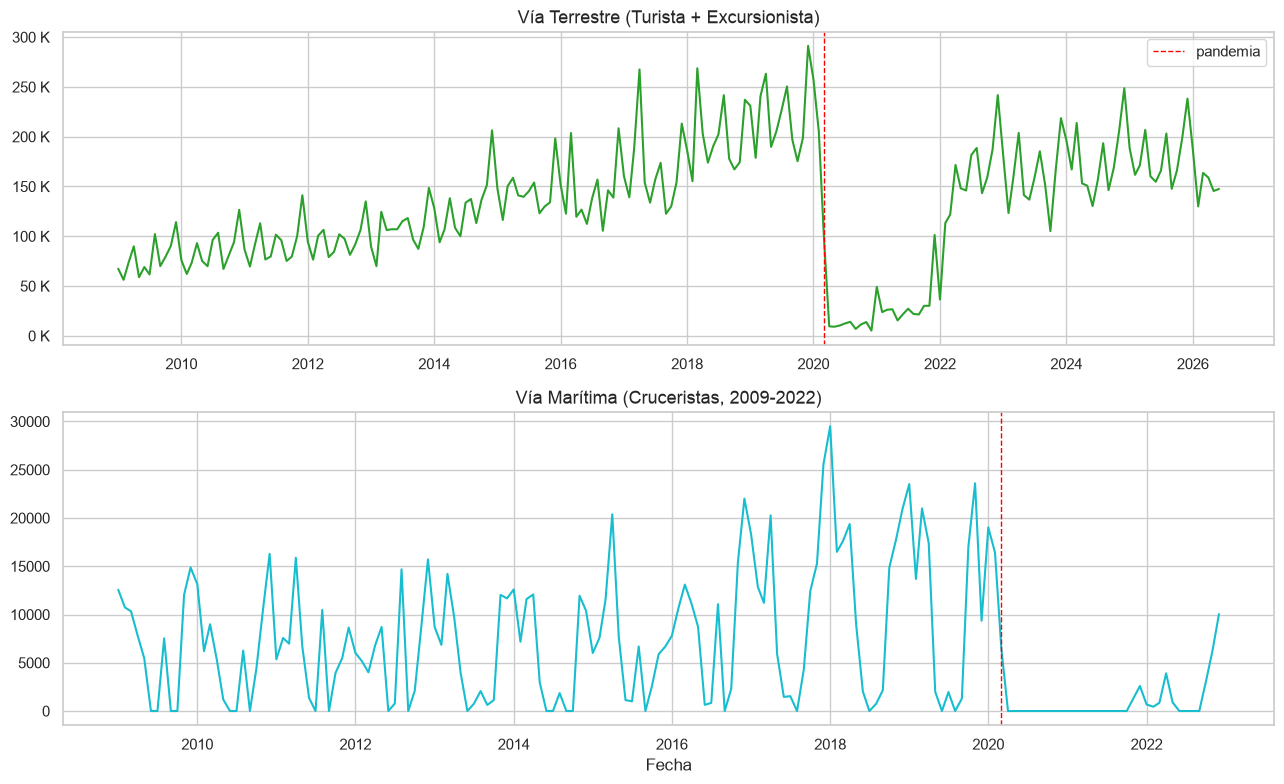

In [31]:
fig, ax = plt.subplots(2, 1, figsize=(13, 8))
ax[0].plot(serie_terrestre.index, serie_terrestre.values, color="#2ca02c")
ax[0].axvline(pd.Timestamp("2020-03-01"), color="red", ls="--", lw=1, label="pandemia")
ax[0].set_title("Vía Terrestre (Turista + Excursionista)"); ax[0].legend()
ax[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f} K"))

ax[1].plot(serie_maritima.index, serie_maritima.values, color="#17becf")
ax[1].axvline(pd.Timestamp("2020-03-01"), color="red", ls="--", lw=1)
ax[1].set_title("Vía Marítima (Cruceristas, 2009-2022)"); ax[1].set_xlabel("Fecha")
plt.tight_layout(); plt.show()

**Interpretación a primera vista.**
- **Terrestre:** la serie más grande en volumen; tendencia creciente marcada hasta 2019, colapso en
  2020–2021 y fuerte recuperación desde 2022. Estacionalidad anual visible. Igual que Total/Aérea:
  a priori **no estacionaria en media ni en varianza**.
- **Marítima (Cruceristas):** dominada por una **estacionalidad extrema** — temporada de cruceros
  (aprox. oct–abr) contra meses de verano casi en cero. Se ve la interrupción total durante la
  pandemia (2020–2021) y una recuperación parcial en 2022. Es una serie **intermitente** (muchos
  ceros), lo que la hace especial para el modelado.

## 14. Análisis preliminar de Terrestre y Marítima

Aplicamos la misma metodología: descomposición, estacionariedad en varianza (transformación) y en
media (ACF + ADF). Reutilizamos las funciones ya definidas.

### 14.1 Terrestre — descomposición y estacionariedad

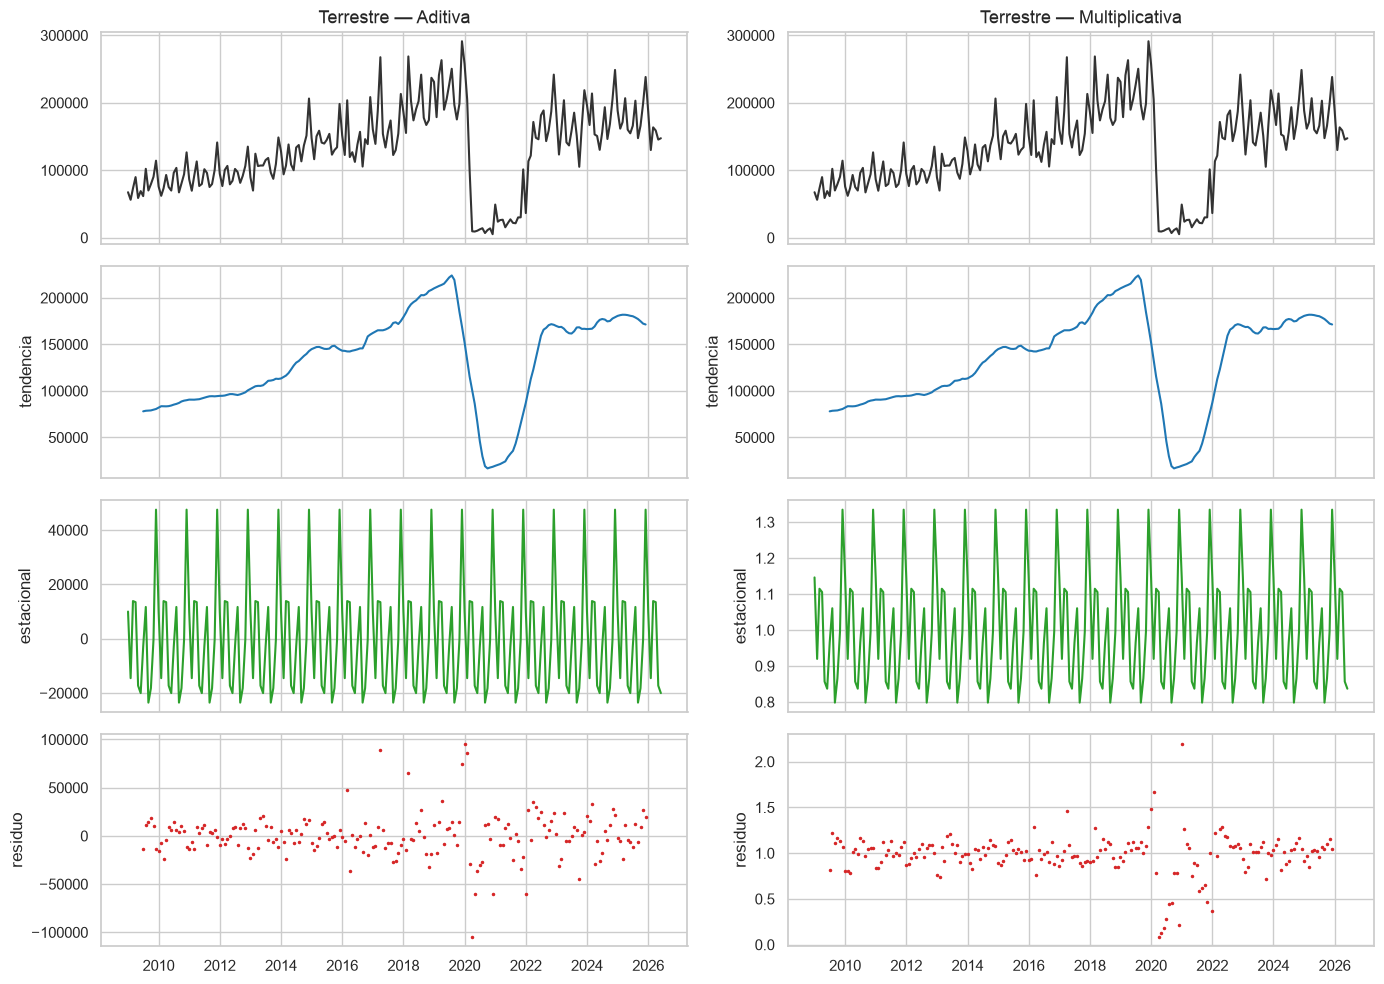

Desv. estándar del residuo -> Aditiva: 22,702.7 | Multiplicativa: 0.2241 (residuo multiplicativo ~1, adimensional)


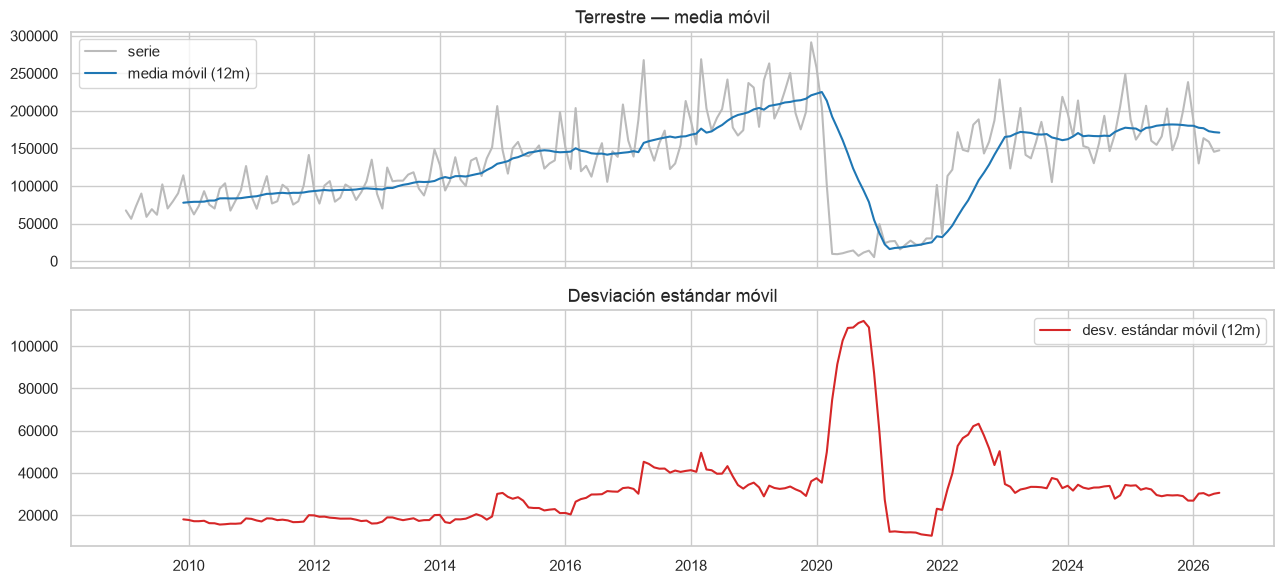

In [32]:
_ = comparar_descomposicion(serie_terrestre, "Terrestre")
media_std_movil(serie_terrestre, "Terrestre")

Terrestre (log) en nivel:
ADF  Terrestre log                    estad= -3.221  p-valor=0.0188  -> ESTACIONARIA
KPSS Terrestre log                    estad=  0.136  p-valor=0.1000  -> ESTACIONARIA

Terrestre (log) tras d=1:
ADF  Terrestre log d=1                estad= -3.541  p-valor=0.0070  -> ESTACIONARIA
KPSS Terrestre log d=1                estad=  0.037  p-valor=0.1000  -> ESTACIONARIA


/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_81875/821220324.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")
/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_81875/821220324.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")


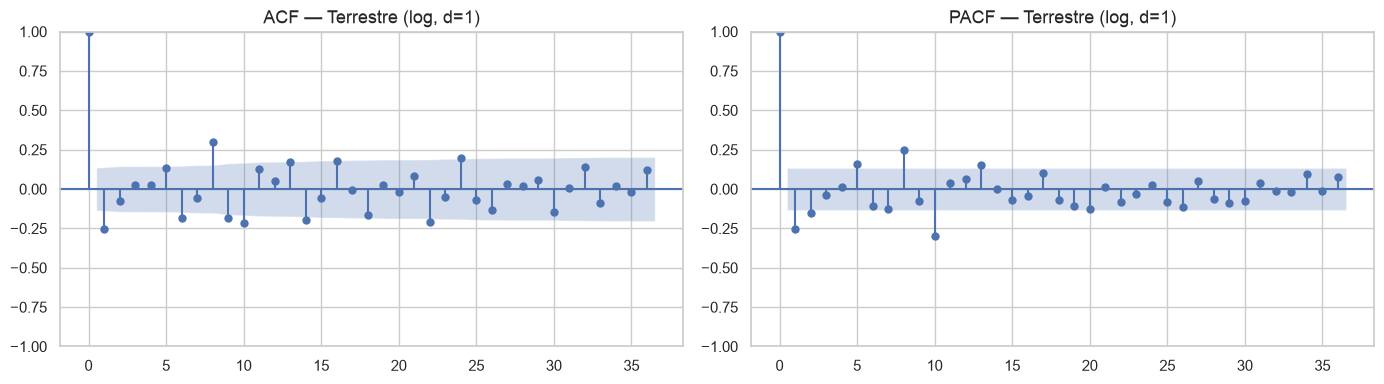

In [33]:
serie_terrestre_log = np.log(serie_terrestre)      # min > 0, log directo
serie_terrestre_d1 = serie_terrestre_log.diff(1).dropna()

print("Terrestre (log) en nivel:")
prueba_adf(serie_terrestre_log, "Terrestre log"); prueba_kpss(serie_terrestre_log, "Terrestre log")
print("\nTerrestre (log) tras d=1:")
prueba_adf(serie_terrestre_d1, "Terrestre log d=1"); prueba_kpss(serie_terrestre_d1, "Terrestre log d=1")
acf_pacf(serie_terrestre_d1, "Terrestre (log, d=1)")

**Interpretación (Terrestre).** Comportamiento análogo a Total/Aérea: estacionalidad multiplicativa
(residuo aditivo en embudo → **log**) y tendencia visible en la descomposición. Como con las otras
series, el ADF en **nivel** es ambiguo por la estacionalidad y el quiebre pandémico (aquí incluso
rechaza en el límite); apoyándonos en la tendencia y la ACF aplicamos **d = 1**, tras lo cual el
diagnóstico es consistente (ADF rechaza, KPSS no rechaza). Persisten picos estacionales en el
rezago 12 → componente SARIMA.

### 14.2 Marítima — descomposición y estacionariedad

La serie es **intermitente** (muchos ceros), por lo que: (1) la descomposición **multiplicativa no
aplica** (división por cero) y usamos solo la **aditiva**; y (2) para transformar la varianza usamos
`np.log1p` (tolera ceros).

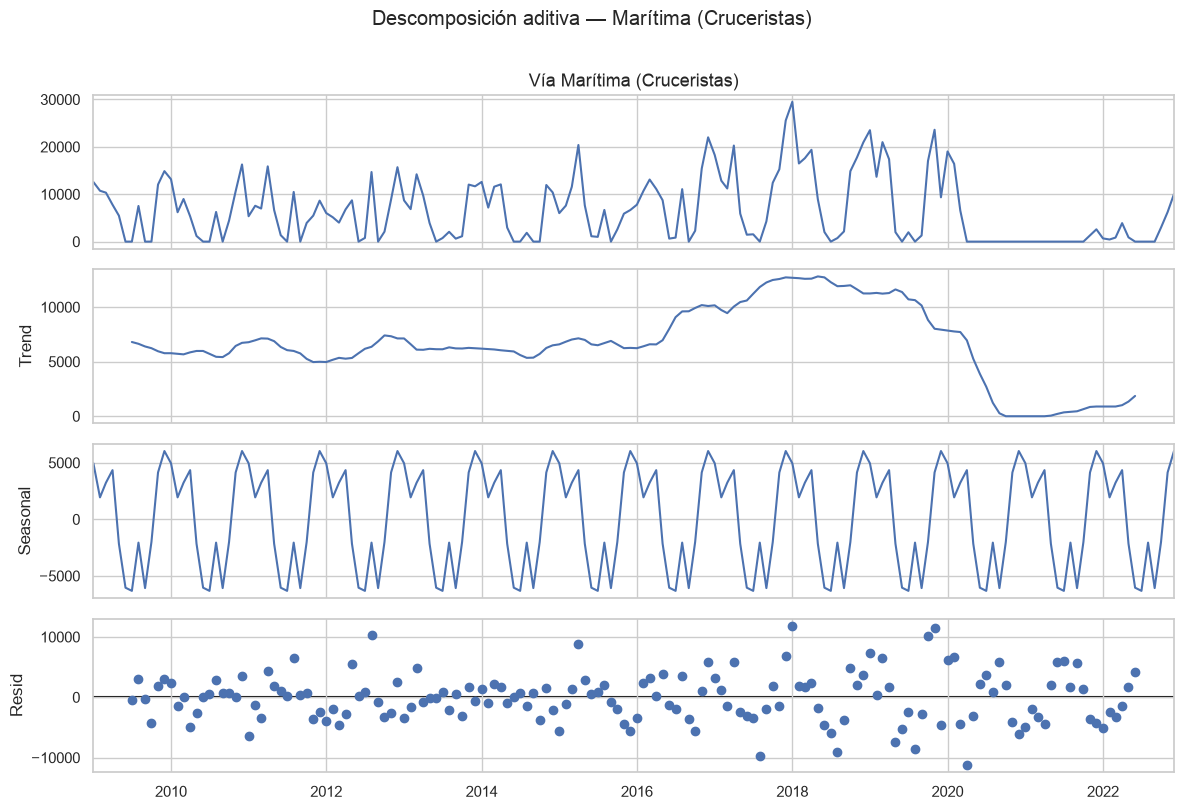

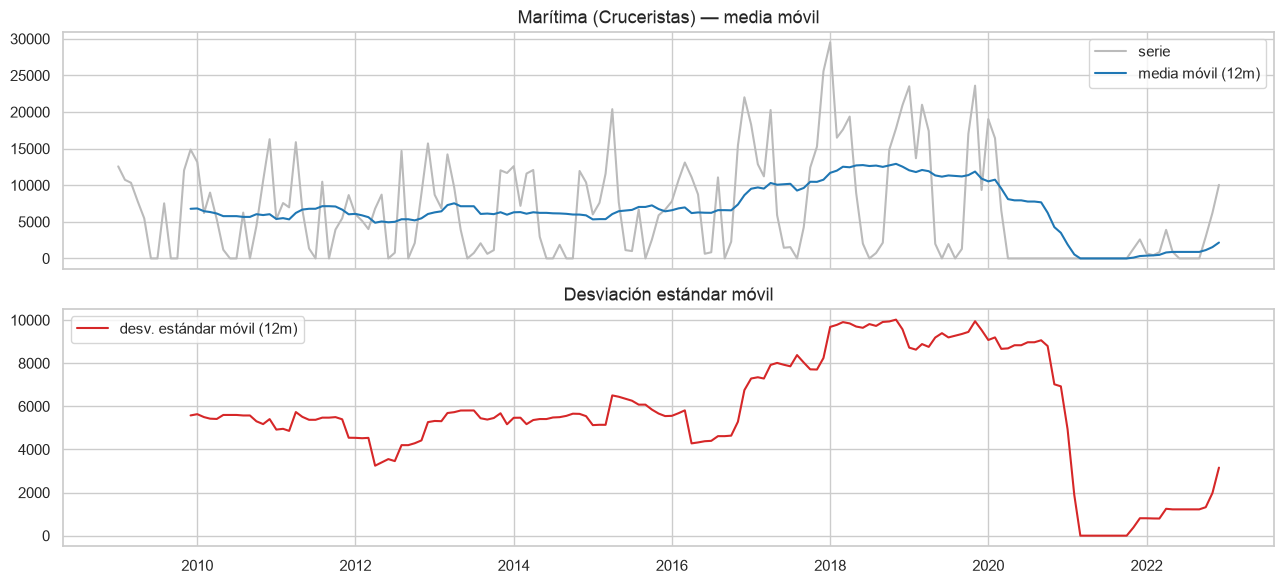

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose
desc_mar = seasonal_decompose(serie_maritima, model="additive", period=12)
fig = desc_mar.plot(); fig.set_size_inches(12, 8)
fig.suptitle("Descomposición aditiva — Marítima (Cruceristas)", y=1.01)
plt.tight_layout(); plt.show()

media_std_movil(serie_maritima, "Marítima (Cruceristas)")

Marítima (log1p) en nivel:
ADF  Marítima log1p                   estad= -2.044  p-valor=0.2678  -> NO estacionaria
KPSS Marítima log1p                   estad=  0.489  p-valor=0.0441  -> NO estacionaria

Marítima (log1p) tras d=1:
ADF  Marítima log1p d=1               estad= -4.006  p-valor=0.0014  -> ESTACIONARIA
KPSS Marítima log1p d=1               estad=  0.023  p-valor=0.1000  -> ESTACIONARIA


/var/folders/75/qq7qyc9j5kd658zsm1nr96mc0000gn/T/ipykernel_81875/821220324.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, *_ = kpss(x.dropna(), regression="c", nlags="auto")


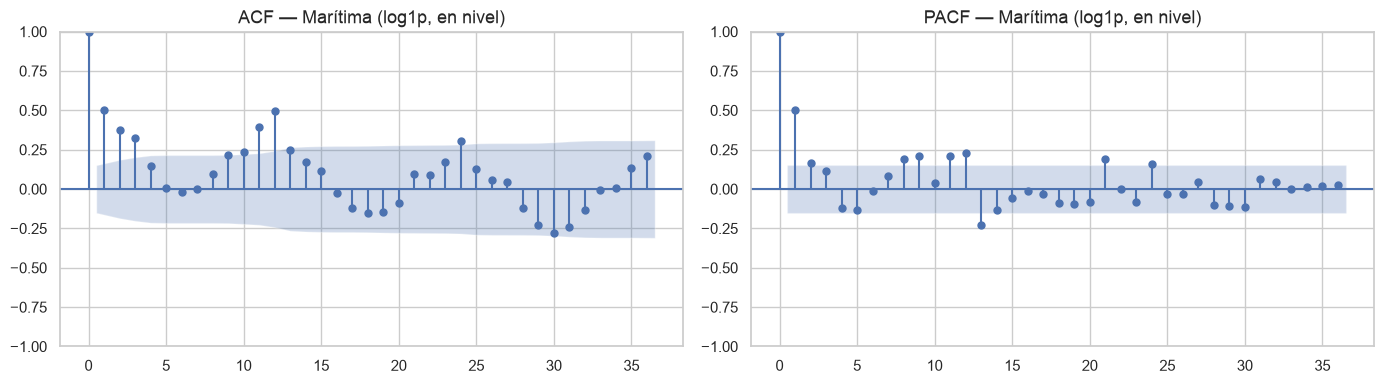

In [35]:
serie_maritima_log = np.log1p(serie_maritima)      # log(1+x) por los ceros
serie_maritima_d1 = serie_maritima_log.diff(1).dropna()

print("Marítima (log1p) en nivel:")
prueba_adf(serie_maritima_log, "Marítima log1p"); prueba_kpss(serie_maritima_log, "Marítima log1p")
print("\nMarítima (log1p) tras d=1:")
prueba_adf(serie_maritima_d1, "Marítima log1p d=1"); prueba_kpss(serie_maritima_d1, "Marítima log1p d=1")
acf_pacf(serie_maritima_log, "Marítima (log1p, en nivel)")

**Interpretación (Marítima).** La **estacionalidad domina** por completo: la descomposición muestra
una componente estacional enorme frente a una tendencia débil. La ACF exhibe picos fuertes en los
rezagos estacionales (12, 24). Por la intermitencia (temporada baja + parón pandémico), esta serie
es candidata natural a un modelo **SARIMA** con fuerte componente estacional (o seasonal naive como
línea base). Se documenta que sus muchos ceros y el corte en 2022 condicionan el modelado.

## 15. Resumen (Notebook 1)

**Análisis exploratorio** — cobertura 2009–jun 2026 (210 meses sin huecos), datos limpios,
concentración en América y vía Terrestre, y efecto claro de la pandemia.

**Series construidas y con análisis preliminar completo** (4 series de este notebook):

| Serie | Definición | Rango | Transformación | d |
|---|---|---|---|---|
| Total | Turista+Excursionista | 2009-01 / 2026-06 | log | 1 |
| Vía Aérea | Turista+Excursionista | 2009-01 / 2026-06 | log | 1 |
| Vía Terrestre | Turista+Excursionista | 2009-01 / 2026-06 | log | 1 |
| Vía Marítima | Cruceristas (intermitente) | 2009-01 / 2022-12 | log1p | 1 (fuerte estacionalidad) |

Todas resultan **no estacionarias en varianza** (→ transformación) y requieren **d = 1** en media,
con estacionalidad de período 12 pendiente de modelar (SARIMA).

**Próximo paso (modelado):** partición 70/30, ARIMA/SARIMA (p,q por ACF/PACF), y Prophet,
Holt-Winters, suavizamiento exponencial y seasonal naive, con métricas MAE/RMSE/AIC/BIC.

> **Series por país de residencia** (El Salvador, EE. UU., Honduras): ver **Notebook 2**
> (`Lab1_Series_Paises.ipynb`).